In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Charger les données
df = pd.read_excel("C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/Antibacterial_activity.xlsx", sheet_name = 'Sheet3')


# Nettoyage léger
df["metabolite"] = df["metabolite"].str.strip()
df["condition"] = df["condition"].str.strip()
df["time"] = df["time"].str.strip()

# Ordre des temps
time_order = ["0h", "12h", "24h"]
df["time"] = pd.Categorical(df["time"], categories=time_order, ordered=True)

# Vérification
print(df.head())

   metabolite time condition  replicate  value
0  Isopulegol   0h   Treated          1  0.232
1  Isopulegol   0h   Treated          2  0.223
2  Isopulegol   0h   Treated          3  0.223
3  Isopulegol   0h   Control          1  0.223
4  Isopulegol   0h   Control          2  0.231


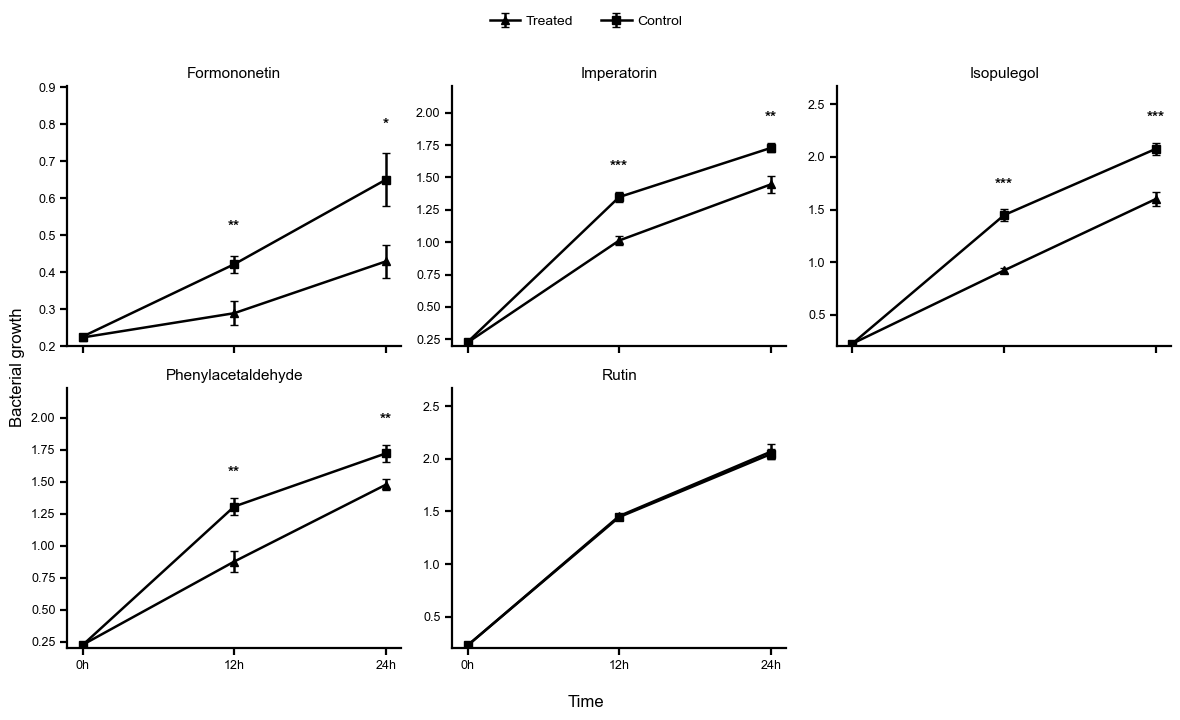

Figure saved.
Statistics table saved.


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind

# =========================
# 1. Load data
# =========================
df = pd.read_excel(
    "C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/Antibacterial_activity.xlsx",
    sheet_name="Sheet3"
)

# =========================
# 2. Clean columns
# =========================
df["metabolite"] = df["metabolite"].astype(str).str.strip()
df["condition"] = df["condition"].astype(str).str.strip()
df["time"] = df["time"].astype(str).str.strip()

# Keep order of time points
time_order = ["0h", "12h", "24h"]
df = df[df["time"].isin(time_order)].copy()
df["time"] = pd.Categorical(df["time"], categories=time_order, ordered=True)

# Condition order
condition_order = ["Treated", "Control"]
df["condition"] = pd.Categorical(df["condition"], categories=condition_order, ordered=True)

# =========================
# 3. Summary statistics
# =========================
summary = (
    df.groupby(["metabolite", "time", "condition"], observed=False)["value"]
    .agg(["mean", "std"])
    .reset_index()
)

# =========================
# 4. Helper functions
# =========================
def p_to_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return ""

# =========================
# 5. Plot settings
# =========================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

metabolites = sorted(df["metabolite"].dropna().unique())

n_met = len(metabolites)
ncols = 3
nrows = int(np.ceil(n_met / ncols))
x = np.arange(len(time_order))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(12, 7),
    sharex=True,
    sharey=False
)
axes = np.array(axes).reshape(-1)

summary_stats = []

# =========================
# 6. Plot each metabolite
# =========================
for i, metabolite in enumerate(metabolites):
    ax = axes[i]
    sub_met = summary[summary["metabolite"] == metabolite]

    # Plot Treated
    sub_treated = sub_met[sub_met["condition"] == "Treated"].sort_values("time")
    ax.errorbar(
        x,
        sub_treated["mean"],
        yerr=sub_treated["std"],
        marker="^",
        linestyle="-",
        linewidth=1.8,
        markersize=6,
        capsize=3,
        color="black",
        markerfacecolor="black",
        markeredgecolor="black",
        label="Treated"
    )

    # Plot Control
    sub_control = sub_met[sub_met["condition"] == "Control"].sort_values("time")
    ax.errorbar(
        x,
        sub_control["mean"],
        yerr=sub_control["std"],
        marker="s",
        linestyle="-",
        linewidth=1.8,
        markersize=6,
        capsize=3,
        color="black",
        markerfacecolor="black",
        markeredgecolor="black",
        label="Control"
    )

    # =========================
    # 7. Significance stars
    # =========================
    panel_max = max(
        (sub_met["mean"] + sub_met["std"]).max(),
        0.01
    )
    base_offset = panel_max * 0.08

    for j, timepoint in enumerate(time_order):
        treated_vals = df[
            (df["metabolite"] == metabolite) &
            (df["time"] == timepoint) &
            (df["condition"] == "Treated")
        ]["value"].values

        control_vals = df[
            (df["metabolite"] == metabolite) &
            (df["time"] == timepoint) &
            (df["condition"] == "Control")
        ]["value"].values

        # Welch t-test
        _, pval = ttest_ind(treated_vals, control_vals, equal_var=False)
        stars = p_to_stars(pval)

        treated_mean = np.mean(treated_vals)
        treated_sd = np.std(treated_vals, ddof=1)

        control_mean = np.mean(control_vals)
        control_sd = np.std(control_vals, ddof=1)

        summary_stats.append({
            "metabolite": metabolite,
            "time": timepoint,
            "treated_mean": treated_mean,
            "treated_sd": treated_sd,
            "control_mean": control_mean,
            "control_sd": control_sd,
            "p_value": pval,
            "significance": stars
        })

        if stars:
            y_top = max(
                treated_mean + treated_sd,
                control_mean + control_sd
            )
            ax.text(
                j,
                y_top + base_offset,
                stars,
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold",
                color="black"
            )

    # =========================
    # 8. Panel formatting
    # =========================
    ax.set_title(metabolite, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(time_order, fontsize=9)

    ax.tick_params(axis="x", labelsize=9, width=1.6, length=5)
    ax.tick_params(axis="y", labelsize=9, width=1.6, length=5)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.6)
    ax.spines["bottom"].set_linewidth(1.6)

    ymin = max(0, (sub_met["mean"] - sub_met["std"]).min() * 0.9)
    ymax = (sub_met["mean"] + sub_met["std"]).max() * 1.25
    ax.set_ylim(ymin, ymax)

# Hide empty panels
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# =========================
# 9. Global labels and legend
# =========================
fig.supxlabel("Time", fontsize=12)
fig.supylabel("Bacterial growth", fontsize=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
    fontsize=10,
    handlelength=2.2,
    handletextpad=0.4
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# =========================
# 10. Save outputs
# =========================
plt.savefig(
    "C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/growth_inhibition_metabolites_black_style.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/growth_inhibition_metabolites_black_style.tif",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# =========================
# 11. Export summary stats
# =========================
summary_stats_df = pd.DataFrame(summary_stats)
summary_stats_df.to_excel(
    "C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/growth_inhibition_stats_black_style.xlsx",
    index=False
)

print("Figure saved.")
print("Statistics table saved.")

In [1]:
import pandas as pd
from scipy.stats import kruskal
import scikit_posthocs as sp

# =========================
# 1. Charger les données
# =========================
# Remplace par ton vrai chemin
df = pd.read_excel(
    "C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/Antibacterial_activity.xlsx",
    sheet_name="Sheet4"
)

# =========================
# 2. Nettoyage
# =========================
df["metabolite"] = df["metabolite"].astype(str).str.strip()
df["time"] = df["time"].astype(str).str.strip()

time_order = ["0h", "12h", "24h"]
df["time"] = pd.Categorical(df["time"], categories=time_order, ordered=True)

# Vérification rapide
print(df.head())
print(df.groupby(["time", "metabolite"]).size())

# =========================
# 3. Kruskal + Dunn par temps
# =========================
for t in time_order:
    sub = df[df["time"] == t].copy()

    print("\n" + "=" * 60)
    print(f"Time = {t}")
    print("=" * 60)

    # Récupérer les groupes d'inhibition par métabolite
    groups = []
    group_names = []

    for met, grp in sub.groupby("metabolite"):
        values = grp["Inhibition"].dropna().values
        if len(values) > 0:
            groups.append(values)
            group_names.append(met)

    # Kruskal-Wallis global
    stat, pval = kruskal(*groups)
    print(f"Kruskal-Wallis: H = {stat:.4f}, p = {pval:.6f}")

    # Moyennes / SD pour aider l'interprétation
    summary = (
        sub.groupby("metabolite")["Inhibition"]
        .agg(["mean", "std", "count"])
        .sort_values("mean", ascending=False)
    )
    print("\nSummary stats:")
    print(summary)

    # Dunn post-hoc si significatif
    if pval < 0.05:
        print("\nDunn post-hoc test (BH corrected p-values):")
        dunn = sp.posthoc_dunn(
            sub,
            val_col="Inhibition",
            group_col="metabolite",
            p_adjust="fdr_bh"
        )
        print(dunn)
    else:
        print("\nNo significant global difference between metabolites at this time.")

   metabolite time condition  replicate  control  Treated  Inhibition
0  Isopulegol   0h   Control          1    0.223    0.232    0.000000
1  Isopulegol   0h   Control          2    0.231    0.223    3.463203
2  Isopulegol   0h   Control          3    0.226    0.223    1.327434
3       Rutin   0h   Control          1    0.231    0.229    0.865801
4       Rutin   0h   Control          2    0.225    0.225    0.000000
time  metabolite        
0h    Formononetin          3
      Imperatorin           3
      Isopulegol            3
      Phenylacetaldehyde    3
      Rutin                 3
12h   Formononetin          3
      Imperatorin           3
      Isopulegol            3
      Phenylacetaldehyde    3
      Rutin                 3
24h   Formononetin          3
      Imperatorin           3
      Isopulegol            3
      Phenylacetaldehyde    3
      Rutin                 3
dtype: int64

Time = 0h
Kruskal-Wallis: H = 4.7846, p = 0.310125

Summary stats:
                        

C:\Users\tamer\AppData\Local\Temp\ipykernel_47828\619813126.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(["time", "metabolite"]).size())


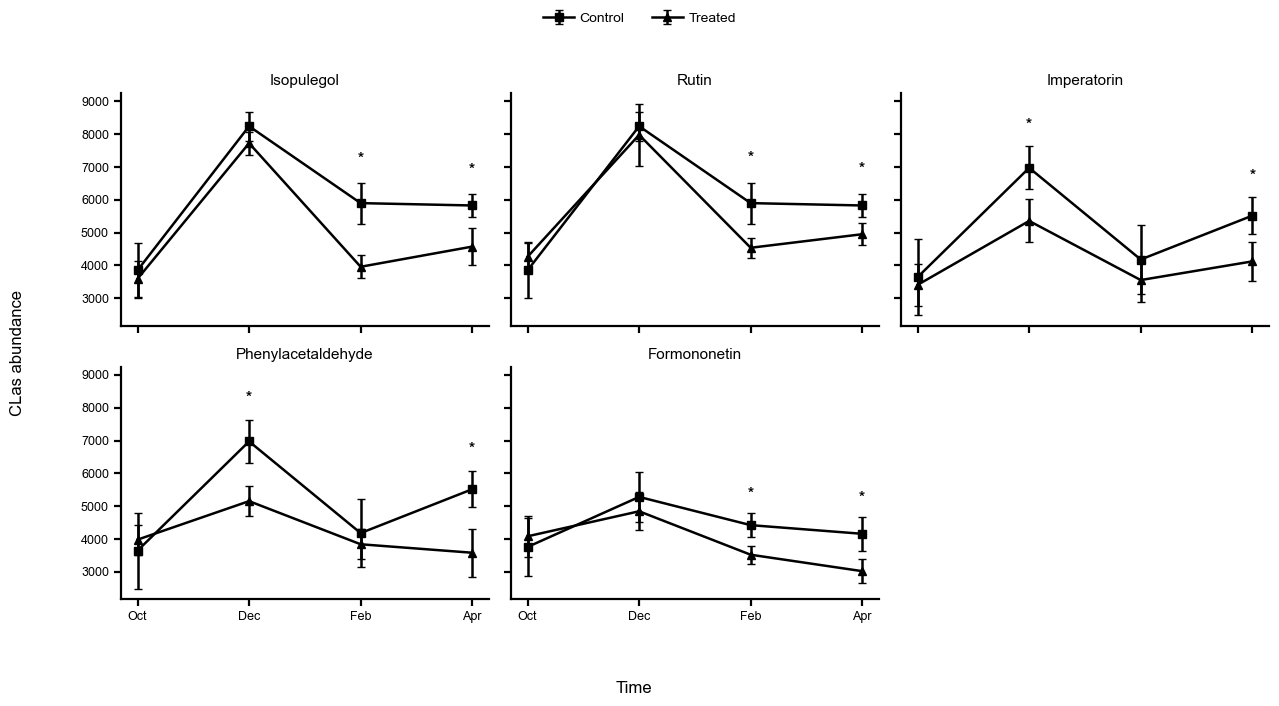

Figure saved as:
 - CLas_timecourse_black_style.png
 - CLas_timecourse_black_style.pdf
 - metabolite_trial_black_style.pdf
 - metabolite_trial_black_style.tif
Summary table saved as:
 - CLas_timecourse_summary_stats_black_style.xlsx


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# =========================================================
# 1. Input data
# =========================================================
data = [
    ["CK 8.5%", 1, 4694.14, 8685.12, 6504.68, 5472.02],
    ["CK 8.5%", 2, 3015.16, 7792.25, 5262.62, 6180.99],
    ["CK 8.5%", 3, 3852.58, 8242.67, 5927.94, 5827.52],

    ["Isopulegol", 1, 3595.65, 8078.43, 3957.25, 4019.81],
    ["Isopulegol", 2, 3047.77, 7366.84, 4309.92, 4577.62],
    ["Isopulegol", 3, 4138.51, 7724.63, 3613.56, 5125.44],

    ["Rutin", 1, 3814.17, 7030.37, 4827.63, 4610.55],
    ["Rutin", 2, 4261.56, 7980.23, 4570.94, 5291.05],
    ["Rutin", 3, 4720.93, 8918.07, 4218.26, 4953.29],

    ["CK 20%", 1, 3647.53, 7629.35, 5222.67, 5518.59],
    ["CK 20%", 2, 2489.09, 6967.84, 3137.82, 6069.43],
    ["CK 20%", 3, 4801.95, 6320.32, 4184.24, 4960.73],

    ["Imperatorin", 1, 4055.11, 6011.97, 4211.98, 4714.42],
    ["Imperatorin", 2, 2761.04, 4702.50, 2905.51, 3539.37],
    ["Imperatorin", 3, 3412.57, 5353.74, 3549.74, 4117.89],

    ["Phenylacetaldehyde", 1, 4449.04, 5611.03, 4301.14, 4308.16],
    ["Phenylacetaldehyde", 2, 3541.81, 4704.05, 3378.01, 2853.53],
    ["Phenylacetaldehyde", 3, 3954.43, 5146.53, 3843.57, 3587.34],

    ["CK 34%", 1, 3757.55, 4509.15, 4785.82, 4680.43],
    ["CK 34%", 2, 4637.22, 6054.12, 4055.35, 3641.36],
    ["CK 34%", 3, 2881.87, 5284.63, 4427.58, 4156.87],

    ["Formononetin", 1, 4085.61, 5429.36, 3774.68, 3374.67],
    ["Formononetin", 2, 4705.34, 4262.81, 3234.76, 2633.78],
    ["Formononetin", 3, 3459.87, 4843.59, 3557.23, 3057.23],
]

df = pd.DataFrame(
    data,
    columns=["Treatment", "Replicate", "Oct", "Dec", "Feb", "Apr"]
)

# =========================================================
# 2. Settings
# =========================================================
time_columns = ["Oct", "Dec", "Feb", "Apr"]
time_labels = ["Oct", "Dec", "Feb", "Apr"]

control_map = {
    "Isopulegol": "CK 8.5%",
    "Rutin": "CK 8.5%",
    "Imperatorin": "CK 20%",
    "Phenylacetaldehyde": "CK 20%",
    "Formononetin": "CK 34%"
}

metabolites = list(control_map.keys())

plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# =========================================================
# 3. Helper functions
# =========================================================
def p_to_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return ""

def summarize_group(df_sub, cols):
    mean_vals = df_sub[cols].mean()
    sd_vals = df_sub[cols].std()
    return mean_vals, sd_vals

# =========================================================
# 4. Create figure
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
axes = axes.flatten()

summary_rows = []

for i, metabolite in enumerate(metabolites):
    ax = axes[i]
    control = control_map[metabolite]

    df_control = df[df["Treatment"] == control]
    df_treated = df[df["Treatment"] == metabolite]

    control_mean, control_sd = summarize_group(df_control, time_columns)
    treated_mean, treated_sd = summarize_group(df_treated, time_columns)

    x = np.arange(len(time_columns))

    # Control = black squares
    ax.errorbar(
        x,
        control_mean.values,
        yerr=control_sd.values,
        marker="s",
        linestyle="-",
        linewidth=1.8,
        markersize=6,
        capsize=3,
        color="black",
        markerfacecolor="black",
        markeredgecolor="black",
        label="Control"
    )

    # Treated = black triangles
    ax.errorbar(
        x,
        treated_mean.values,
        yerr=treated_sd.values,
        marker="^",
        linestyle="-",
        linewidth=1.8,
        markersize=6,
        capsize=3,
        color="black",
        markerfacecolor="black",
        markeredgecolor="black",
        label="Treated"
    )

    # Add significance stars
    panel_max = max(
        (treated_mean + treated_sd).max(),
        (control_mean + control_sd).max()
    )
    base_offset = panel_max * 0.06

    for j, col in enumerate(time_columns):
        treated_vals = df_treated[col].values
        control_vals = df_control[col].values

        _, pval = ttest_ind(treated_vals, control_vals, equal_var=False)
        stars = p_to_stars(pval)

        summary_rows.append({
            "Metabolite": metabolite,
            "Time": col,
            "Control_mean": control_mean[col],
            "Control_SD": control_sd[col],
            "Treated_mean": treated_mean[col],
            "Treated_SD": treated_sd[col],
            "p_value": pval,
            "Significance": stars
        })

        if stars:
            y_top = max(
                treated_mean[col] + treated_sd[col],
                control_mean[col] + control_sd[col]
            )

            ax.text(
                j,
                y_top + base_offset,
                stars,
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold",
                color="black"
            )

    # Panel formatting
    ax.set_title(metabolite, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(time_labels, fontsize=9)
    ax.tick_params(axis="y", labelsize=9, width=1.6, length=5)
    ax.tick_params(axis="x", labelsize=9, width=1.6, length=5)

    # Style like publication figure
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.6)
    ax.spines["bottom"].set_linewidth(1.6)

# Remove empty last panel
fig.delaxes(axes[-1])

# Global labels
fig.supxlabel("Time", fontsize=12)
fig.supylabel("CLas abundance", fontsize=12)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    fontsize=10,
    handlelength=2.2,
    handletextpad=0.4
)

plt.tight_layout(rect=[0.04, 0.05, 1, 0.92])

# =========================================================
# 5. Save figure
# =========================================================
plt.savefig("CLas_timecourse_black_style.png", dpi=300, bbox_inches="tight")
plt.savefig("CLas_timecourse_black_style.pdf", bbox_inches="tight")

plt.savefig(
    "C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/metabolite_trial_black_style.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/metabolite_trial_black_style.tif",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# 6. Export summary statistics
# =========================================================
summary_df = pd.DataFrame(summary_rows)
summary_df.to_excel("CLas_timecourse_summary_stats_black_style.xlsx", index=False)

print("Figure saved as:")
print(" - CLas_timecourse_black_style.png")
print(" - CLas_timecourse_black_style.pdf")
print(" - metabolite_trial_black_style.pdf")
print(" - metabolite_trial_black_style.tif")
print("Summary table saved as:")
print(" - CLas_timecourse_summary_stats_black_style.xlsx")

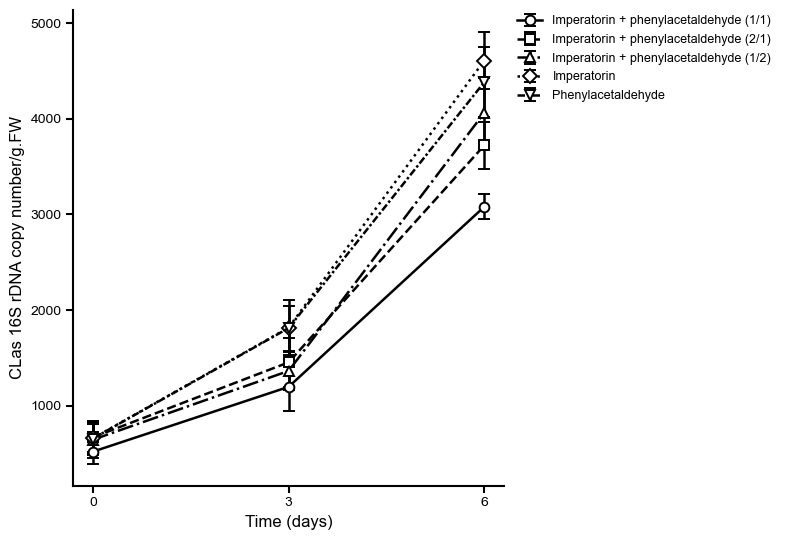

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. Input data
# =========================================================
data = [
    ["Imperatorin + phenylacetaldehyde", "1/1", 520.37, 129.29, 1197.58, 253.02, 3079.55, 129.03],
    ["Imperatorin + phenylacetaldehyde", "2/1", 670.25, 157.26, 1453.57, 256.94, 3721.65, 245.96],
    ["Imperatorin + phenylacetaldehyde", "1/2", 645.15, 191.41, 1363.98, 202.71, 4062.33, 362.02],
    ["Imperatorin", "", 659.68, 152.41, 1816.74, 283.67, 4608.40, 301.86],
    ["Phenylacetaldehyde", "", 657.56, 170.71, 1812.05, 234.59, 4382.49, 362.19],
]

df = pd.DataFrame(
    data,
    columns=[
        "Treatment", "Ratio",
        "Day0_mean", "Day0_sd",
        "Day3_mean", "Day3_sd",
        "Day6_mean", "Day6_sd"
    ]
)

# =========================================================
# 2. Settings
# =========================================================
time_points = [0, 3, 6]
mean_cols = ["Day0_mean", "Day3_mean", "Day6_mean"]
sd_cols   = ["Day0_sd",   "Day3_sd",   "Day6_sd"]

plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# Different markers for each condition
marker_map = {
    "Imperatorin + phenylacetaldehyde_1/1": "o",
    "Imperatorin + phenylacetaldehyde_2/1": "s",
    "Imperatorin + phenylacetaldehyde_1/2": "^",
    "Imperatorin_": "D",
    "Phenylacetaldehyde_": "v",
}

# Optional line styles
linestyle_map = {
    "Imperatorin + phenylacetaldehyde_1/1": "-",
    "Imperatorin + phenylacetaldehyde_2/1": "--",
    "Imperatorin + phenylacetaldehyde_1/2": "-.",
    "Imperatorin_": ":",
    "Phenylacetaldehyde_": (0, (3, 1, 1, 1)),
}

# =========================================================
# 3. Create figure
# =========================================================
fig, ax = plt.subplots(figsize=(8, 5.5))

for _, row in df.iterrows():
    key = f"{row['Treatment']}_{row['Ratio']}"
    
    means = row[mean_cols].values.astype(float)
    sds = row[sd_cols].values.astype(float)

    if row["Ratio"] != "":
        label = f"{row['Treatment']} ({row['Ratio']})"
    else:
        label = row["Treatment"]

    ax.errorbar(
        time_points,
        means,
        yerr=sds,
        marker=marker_map.get(key, "o"),
        linestyle=linestyle_map.get(key, "-"),
        linewidth=1.8,
        markersize=7,
        capsize=4,
        color="black",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.4,
        label=label
    )

# =========================================================
# 4. Formatting
# =========================================================
ax.set_xlabel("Time (days)", fontsize=12)
ax.set_ylabel("CLas 16S rDNA copy number/g.FW", fontsize=12)
ax.set_xticks(time_points)
ax.set_xticklabels([str(x) for x in time_points], fontsize=10)

ax.tick_params(axis="y", labelsize=10, width=1.5, length=5)
ax.tick_params(axis="x", labelsize=10, width=1.5, length=5)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

ax.legend(
    frameon=False,
    fontsize=9,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)

plt.tight_layout()

# =========================================================
# 5. Save
# =========================================================
plt.savefig("C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/Double traitement/1st_trunk_plot.pdf", bbox_inches="tight")
plt.savefig("C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/Double traitement/1st_trunk_plot.tif", dpi=600, bbox_inches="tight")

plt.show()

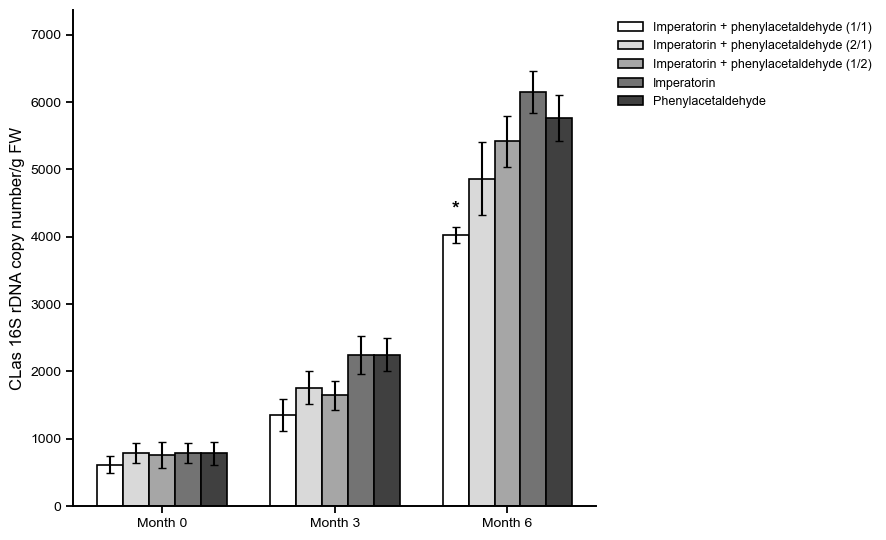

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. Input data
# =========================================================
data = [
    ["Imperatorin + phenylacetaldehyde", "1/1", 617.24, 124.46, 1357.26, 241.75, 4026.54, 118.54],
    ["Imperatorin + phenylacetaldehyde", "2/1", 784.26, 147.21, 1756.24, 246.25, 4863.54, 546.37],
    ["Imperatorin + phenylacetaldehyde", "1/2", 759.58, 189.46, 1649.75, 214.55, 5417.43, 374.22],
    ["Imperatorin", "", 784.54, 148.53, 2246.37, 276.59, 6147.84, 314.89],
    ["Phenylacetaldehyde", "", 784.23, 165.41, 2248.76, 247.16, 5762.87, 341.53],
]

df = pd.DataFrame(
    data,
    columns=[
        "Treatment", "Ratio",
        "M0_mean", "M0_sd",
        "M3_mean", "M3_sd",
        "M6_mean", "M6_sd"
    ]
)

# =========================================================
# 2. Labels
# =========================================================
def make_label(row):
    if row["Ratio"] != "":
        return f"{row['Treatment']} ({row['Ratio']})"
    return row["Treatment"]

df["Label"] = df.apply(make_label, axis=1)

# =========================================================
# 3. Plot settings
# =========================================================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

time_points = ["Month 0", "Month 3", "Month 6"]
x = np.arange(len(time_points))

n_treatments = len(df)
bar_width = 0.15
offsets = (np.arange(n_treatments) - (n_treatments - 1) / 2) * bar_width

fig, ax = plt.subplots(figsize=(9, 5.5))

# =========================================================
# 4. Style maps
# =========================================================
color_map = {
    "Imperatorin + phenylacetaldehyde (1/1)": "white",
    "Imperatorin + phenylacetaldehyde (2/1)": "#d9d9d9",
    "Imperatorin + phenylacetaldehyde (1/2)": "#a6a6a6",
    "Imperatorin": "#737373",
    "Phenylacetaldehyde": "#404040",
}

# =========================================================
# 5. Draw bars
# =========================================================
bar_positions = {}

for i, row in df.iterrows():
    means = [row["M0_mean"], row["M3_mean"], row["M6_mean"]]
    sds   = [row["M0_sd"],   row["M3_sd"],   row["M6_sd"]]
    label = row["Label"]

    current_x = x + offsets[i]

    ax.bar(
        current_x,
        means,
        width=bar_width,
        yerr=sds,
        capsize=3,
        color=color_map.get(label, "white"),
        edgecolor="black",
        linewidth=1.2,
        label=label
    )

    bar_positions[label] = {
        "x": current_x,
        "means": means,
        "sds": sds
    }

# =========================================================
# 6. Add significance asterisk
# =========================================================
target_label = "Imperatorin + phenylacetaldehyde (1/1)"

# Month 6 only
idx = 2
xpos = bar_positions[target_label]["x"][idx]
mean = bar_positions[target_label]["means"][idx]
sd   = bar_positions[target_label]["sds"][idx]

ax.text(
    xpos,
    mean + sd + 120,
    "*",
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold"
)

# =========================================================
# 7. Axis formatting
# =========================================================
ymax = max(
    (df["M0_mean"] + df["M0_sd"]).max(),
    (df["M3_mean"] + df["M3_sd"]).max(),
    (df["M6_mean"] + df["M6_sd"]).max()
)

ax.set_ylim(0, ymax * 1.14)
ax.set_xticks(x)
ax.set_xticklabels(time_points, fontsize=11)

ax.set_ylabel("CLas 16S rDNA copy number/g FW", fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.4)
ax.spines["bottom"].set_linewidth(1.4)

ax.tick_params(axis="y", labelsize=10, width=1.3, length=5)
ax.tick_params(axis="x", labelsize=10, width=1.3, length=5)

# =========================================================
# 8. Legend
# =========================================================
ax.legend(
    frameon=False,
    fontsize=9,
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

# =========================================================
# 9. Save
# =========================================================
plt.tight_layout()

plt.savefig(
    "C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/Double traitement/1st_trunk_chart_new.pdf",
    bbox_inches="tight"
)
plt.savefig(
    "C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/Double traitement/1st_trunk_chart_new.tif",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

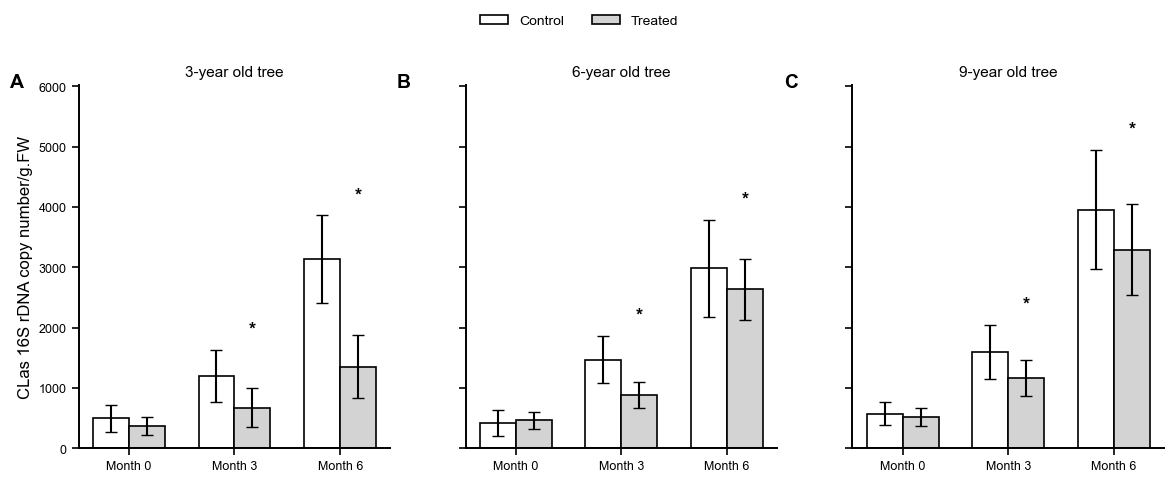

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# =========================================================
# 1. Input data
# =========================================================
data = [
    ["9-year old tree", "Treated", "518.29 ±145.58",  "1161.44±293.39*", "3293.35±756.52*"],
    ["9-year old tree", "Control", "575.09±193.83",   "1601.58±446.05",  "3954.70±987.95"],

    ["6-year old tree", "Treated", "460.51±137.36",   "879.66±218.12*",  "2635.09±508.37*"],
    ["6-year old tree", "Control", "419.81±217.76",   "1469.73±391.62",  "2983.54±803.71"],

    ["3-year old tree", "Treated", "369.31±149.39",   "673.03±326.93*",  "1348.92±522.54*"],
    ["3-year old tree", "Control", "494.50±220.53",   "1204.50±431.09",  "3138.61±725.38"],
]

df = pd.DataFrame(
    data,
    columns=["Plants", "Treatment", "Month 0", "Month 3", "Month 6"]
)

# =========================================================
# 2. Parse mean, SD, and star from text
# =========================================================
time_columns = ["Month 0", "Month 3", "Month 6"]

def parse_value(cell):
    """
    Parse strings like:
    518.29 ±145.58
    1161.44±293.39*
    Returns: mean, sd, has_star
    """
    text = str(cell).replace(" ", "")
    has_star = "*" in text
    text = text.replace("*", "")

    parts = re.split(r"±", text)
    mean_val = float(parts[0])
    sd_val = float(parts[1])

    return mean_val, sd_val, has_star

for col in time_columns:
    df[f"{col}_mean"] = df[col].apply(lambda x: parse_value(x)[0])
    df[f"{col}_sd"]   = df[col].apply(lambda x: parse_value(x)[1])
    df[f"{col}_star"] = df[col].apply(lambda x: parse_value(x)[2])

# =========================================================
# 3. Order panels
# =========================================================
plant_order = ["3-year old tree", "6-year old tree", "9-year old tree"]
panel_labels = ["A", "B", "C"]

# =========================================================
# 4. Plot settings
# =========================================================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

fig, axes = plt.subplots(1, 3, figsize=(12, 4.8), sharey=True)

time_points = ["Month 0", "Month 3", "Month 6"]
x = np.arange(len(time_points))
bar_width = 0.34

# compute common ymax including SD and space for stars
all_tops = []
for col in time_columns:
    all_tops.extend((df[f"{col}_mean"] + df[f"{col}_sd"]).tolist())
ymax = max(all_tops) * 1.22

# =========================================================
# 5. Draw panels
# =========================================================
for ax, plant, panel in zip(axes, plant_order, panel_labels):
    sub = df[df["Plants"] == plant].copy()

    treated = sub[sub["Treatment"] == "Treated"].iloc[0]
    control = sub[sub["Treatment"] == "Control"].iloc[0]

    treated_means = [treated[f"{t}_mean"] for t in time_points]
    treated_sds   = [treated[f"{t}_sd"] for t in time_points]
    treated_stars = [treated[f"{t}_star"] for t in time_points]

    control_means = [control[f"{t}_mean"] for t in time_points]
    control_sds   = [control[f"{t}_sd"] for t in time_points]

    # Control bars
    ax.bar(
        x - bar_width/2,
        control_means,
        width=bar_width,
        yerr=control_sds,
        capsize=4,
        color="white",
        edgecolor="black",
        linewidth=1.2,
        label="Control"
    )

    # Treated bars
    ax.bar(
        x + bar_width/2,
        treated_means,
        width=bar_width,
        yerr=treated_sds,
        capsize=4,
        color="lightgray",
        edgecolor="black",
        linewidth=1.2,
        label="Treated"
    )

    # Add stars only where present in treated row
    for i, has_star in enumerate(treated_stars):
        if has_star:
            y_top = max(
                control_means[i] + control_sds[i],
                treated_means[i] + treated_sds[i]
            )
            ax.text(
                x[i] + bar_width/2,
                y_top + ymax * 0.03,
                "*",
                ha="center",
                va="bottom",
                fontsize=13,
                fontweight="bold"
            )

    # Panel label
    ax.text(
        -0.22, 1.03, panel,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
        ha="left"
    )

    # Panel title
    ax.set_title(plant, fontsize=11)

    # Axes
    ax.set_xticks(x)
    ax.set_xticklabels(time_points, fontsize=10)
    ax.set_ylim(0, ymax)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.4)
    ax.spines["bottom"].set_linewidth(1.4)

    ax.tick_params(axis="y", labelsize=9, width=1.2, length=5)
    ax.tick_params(axis="x", labelsize=9, width=1.2, length=5)

# =========================================================
# 6. Shared labels and legend
# =========================================================
axes[0].set_ylabel("CLas 16S rDNA copy number/g.FW", fontsize=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, 1.03)
)

plt.tight_layout(rect=[0.02, 0.02, 1, 0.93])

# =========================================================
# 7. Save
# =========================================================
# plt.savefig("tree_age_treatment_panels.pdf", bbox_inches="tight")
# plt.savefig("tree_age_treatment_panels.tif", dpi=600, bbox_inches="tight")

plt.show()

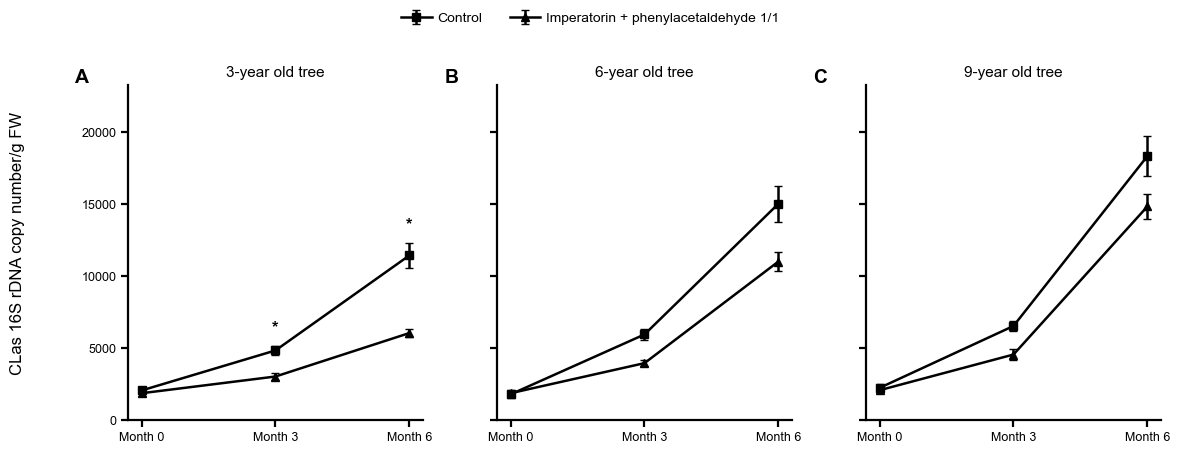

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# =========================================================
# 1. Input data
# =========================================================
data = [
    ["3-year old tree", "Treated", "1874.26±168.56", "3036.49±221.29*", "6056.77±303.67*"],
    ["3-year old tree", "Control", "2067.48±217.28", "4849.18±334.25", "11453.96±879.07"],

    ["6-year old tree", "Treated", "1875.76±228.61", "3965.21±217.90", "11024.33±656.85"],
    ["6-year old tree", "Control", "1797.21±253.77", "5959.75±404.09", "15042.48±1254.24"],

    ["9-year old tree", "Treated", "2084.54±168.06", "4564.17±405.28", "14854.26±892.52"],
    ["9-year old tree", "Control", "2246.37±238.82", "6548.43±337.47", "18354.81±1370.59"],
]

df = pd.DataFrame(data, columns=["Plants", "Treatment", "Month 0", "Month 3", "Month 6"])

# =========================================================
# 2. Settings
# =========================================================
time_columns = ["Month 0", "Month 3", "Month 6"]
time_labels = ["Month 0", "Month 3", "Month 6"]
time_x = np.arange(len(time_columns))

plant_order = ["3-year old tree", "6-year old tree", "9-year old tree"]
panel_labels = ["A", "B", "C"]

plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# =========================================================
# 3. Helper function to parse mean ± SD and star
# =========================================================
def parse_mean_sd_star(text):
    text = str(text).replace(" ", "").replace("–", "-")
    has_star = "*" in text
    text = text.replace("*", "")
    mean_str, sd_str = re.split(r"±", text)
    return float(mean_str), float(sd_str), has_star

for col in time_columns:
    df[f"{col}_mean"] = df[col].apply(lambda x: parse_mean_sd_star(x)[0])
    df[f"{col}_sd"] = df[col].apply(lambda x: parse_mean_sd_star(x)[1])
    df[f"{col}_star"] = df[col].apply(lambda x: parse_mean_sd_star(x)[2])

# =========================================================
# 4. Compute common Y max
# =========================================================
ymax = 0
for col in time_columns:
    ymax = max(ymax, (df[f"{col}_mean"] + df[f"{col}_sd"]).max())
ymax = ymax * 1.18

# =========================================================
# 5. Create figure
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(12, 4.8), sharex=True, sharey=True)
axes = axes.flatten()

for i, plant in enumerate(plant_order):
    ax = axes[i]
    sub = df[df["Plants"] == plant]

    treated = sub[sub["Treatment"] == "Treated"].iloc[0]
    control = sub[sub["Treatment"] == "Control"].iloc[0]

    treated_mean = [treated[f"{col}_mean"] for col in time_columns]
    treated_sd   = [treated[f"{col}_sd"] for col in time_columns]
    treated_star = [treated[f"{col}_star"] for col in time_columns]

    control_mean = [control[f"{col}_mean"] for col in time_columns]
    control_sd   = [control[f"{col}_sd"] for col in time_columns]

    # Control = black squares
    ax.errorbar(
        time_x,
        control_mean,
        yerr=control_sd,
        marker="s",
        linestyle="-",
        linewidth=1.8,
        markersize=6,
        capsize=3,
        color="black",
        markerfacecolor="black",
        markeredgecolor="black",
        label="Control"
    )

    # Treated = filled black triangles
    ax.errorbar(
        time_x,
        treated_mean,
        yerr=treated_sd,
        marker="^",
        linestyle="-",
        linewidth=1.8,
        markersize=6,
        capsize=3,
        color="black",
        markerfacecolor="black",
        markeredgecolor="black",
        label="Imperatorin + phenylacetaldehyde 1/1"
    )

    # Add stars only where present in treated data
    panel_max = max(
        max(np.array(control_mean) + np.array(control_sd)),
        max(np.array(treated_mean) + np.array(treated_sd))
    )
    base_offset = panel_max * 0.06

    for j, has_star in enumerate(treated_star):
        if has_star:
            y_top = max(
                control_mean[j] + control_sd[j],
                treated_mean[j] + treated_sd[j]
            )
            ax.text(
                j,
                y_top + base_offset,
                "*",
                ha="center",
                va="bottom",
                fontsize=12,
                fontweight="bold",
                color="black"
            )

    # Panel label
    ax.text(
        -0.18, 1.05, panel_labels[i],
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        ha="left",
        va="top"
    )

    # Panel formatting
    ax.set_title(plant, fontsize=11)
    ax.set_xticks(time_x)
    ax.set_xticklabels(time_labels, fontsize=9)
    ax.set_ylim(0, ymax)

    ax.tick_params(axis="y", labelsize=9, width=1.6, length=5)
    ax.tick_params(axis="x", labelsize=9, width=1.6, length=5)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.6)
    ax.spines["bottom"].set_linewidth(1.6)

# =========================================================
# 6. Global labels and legend
# =========================================================
fig.supylabel("CLas 16S rDNA copy number/g FW", fontsize=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    fontsize=10,
    handlelength=2.2,
    handletextpad=0.4
)

plt.tight_layout(rect=[0.04, 0.05, 1, 0.90])

# =========================================================
# 7. Save
# =========================================================
plt.savefig(
    "C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/Double traitement/2nd_trunk_chart.pdf",
    bbox_inches="tight"
)
plt.savefig(
    "C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/Double traitement/2nd_trunk_chart.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# Severe tree

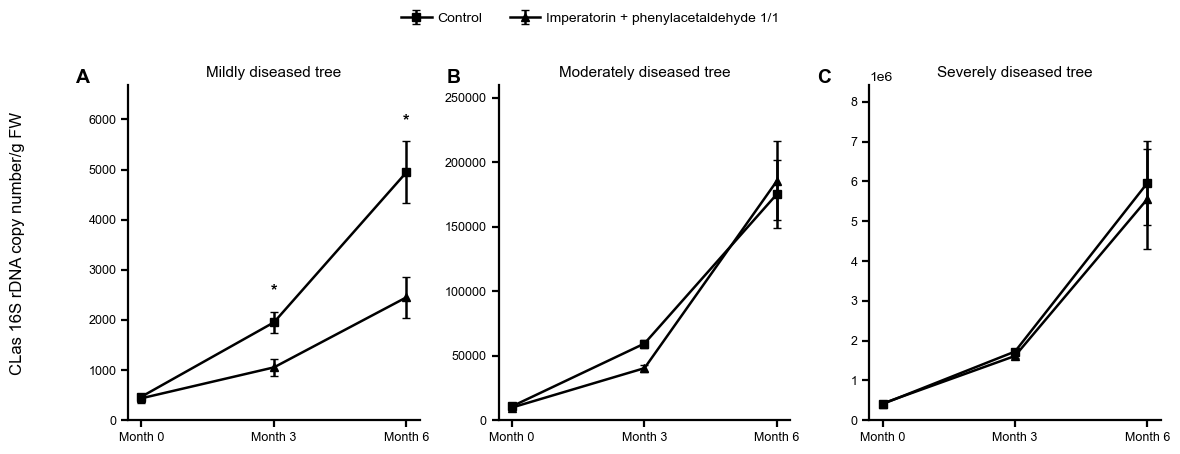

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# =========================================================
# 1. Input data
# =========================================================
data = [
    ["Mildly diseased tree", "Treated", "437.24±89.51", "1053.81±168.21*", "2451.43±405.11*"],
    ["Mildly diseased tree", "Control", "469.22±61.38", "1952.47±212.64",  "4946.39±620.21"],

    ["Moderately diseased tree", "Treated", "9826.49±1522.70",  "40367.86±2648.13",   "185693.45±30754.36"],
    ["Moderately diseased tree", "Control", "10754.23±2033.89", "59474.86±3106.30",   "175432.42±26631.48"],

    ["Severely diseased tree", "Treated", "418532.64±59935.13", "1614739.58±40512.09",  "5563047.07±1251383.37"],
    ["Severely diseased tree", "Control", "405704.33±34909.15",  "1725449.74±25917.46",   "5965914.32±1047704.97"],
]

df = pd.DataFrame(data, columns=["Plants", "Treatment", "Month 0", "Month 3", "Month 6"])

# =========================================================
# 2. Settings
# =========================================================
time_columns = ["Month 0", "Month 3", "Month 6"]
time_labels = ["Month 0", "Month 3", "Month 6"]
time_x = np.arange(len(time_columns))

plant_order = ["Mildly diseased tree", "Moderately diseased tree", "Severely diseased tree"]
panel_labels = ["A", "B", "C"]

plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# =========================================================
# 3. Helper function to parse mean ± SD and star
# =========================================================
def parse_mean_sd_star(text):
    text = str(text).replace(" ", "")
    has_star = "*" in text
    text = text.replace("*", "")
    mean_str, sd_str = re.split(r"±", text)
    return float(mean_str), float(sd_str), has_star

for col in time_columns:
    df[f"{col}_mean"] = df[col].apply(lambda x: parse_mean_sd_star(x)[0])
    df[f"{col}_sd"] = df[col].apply(lambda x: parse_mean_sd_star(x)[1])
    df[f"{col}_star"] = df[col].apply(lambda x: parse_mean_sd_star(x)[2])

# =========================================================
# 4. Create figure
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(12, 4.8), sharex=True, sharey=False)
axes = axes.flatten()

for i, plant in enumerate(plant_order):
    ax = axes[i]
    sub = df[df["Plants"] == plant]

    treated = sub[sub["Treatment"] == "Treated"].iloc[0]
    control = sub[sub["Treatment"] == "Control"].iloc[0]

    treated_mean = [treated[f"{col}_mean"] for col in time_columns]
    treated_sd   = [treated[f"{col}_sd"] for col in time_columns]
    treated_star = [treated[f"{col}_star"] for col in time_columns]

    control_mean = [control[f"{col}_mean"] for col in time_columns]
    control_sd   = [control[f"{col}_sd"] for col in time_columns]

    # Compute panel-specific ymax
    panel_ymax = max(
        max(np.array(control_mean) + np.array(control_sd)),
        max(np.array(treated_mean) + np.array(treated_sd))
    ) * 1.20

    # Control = black filled squares
    ax.errorbar(
        time_x,
        control_mean,
        yerr=control_sd,
        marker="s",
        linestyle="-",
        linewidth=1.8,
        markersize=6,
        capsize=3,
        color="black",
        markerfacecolor="black",
        markeredgecolor="black",
        label="Control"
    )

    # Treated = black filled triangles
    ax.errorbar(
        time_x,
        treated_mean,
        yerr=treated_sd,
        marker="^",
        linestyle="-",
        linewidth=1.8,
        markersize=6,
        capsize=3,
        color="black",
        markerfacecolor="black",
        markeredgecolor="black",
        label="Imperatorin + phenylacetaldehyde 1/1"
    )

    # Add stars only where present in treated data
    base_offset = panel_ymax * 0.04

    for j, has_star in enumerate(treated_star):
        if has_star:
            y_top = max(
                control_mean[j] + control_sd[j],
                treated_mean[j] + treated_sd[j]
            )
            ax.text(
                j,
                y_top + base_offset,
                "*",
                ha="center",
                va="bottom",
                fontsize=12,
                fontweight="bold",
                color="black"
            )

    # Panel label
    ax.text(
        -0.18, 1.05, panel_labels[i],
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        ha="left",
        va="top"
    )

    # Panel formatting
    ax.set_title(plant, fontsize=11)
    ax.set_xticks(time_x)
    ax.set_xticklabels(time_labels, fontsize=9)
    ax.set_ylim(0, panel_ymax)

    ax.tick_params(axis="y", labelsize=9, width=1.6, length=5)
    ax.tick_params(axis="x", labelsize=9, width=1.6, length=5)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.6)
    ax.spines["bottom"].set_linewidth(1.6)

# =========================================================
# 5. Global labels and legend
# =========================================================
fig.supylabel("CLas 16S rDNA copy number/g FW", fontsize=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    fontsize=10,
    handlelength=2.2,
    handletextpad=0.4
)

plt.tight_layout(rect=[0.04, 0.05, 1, 0.90])

# =========================================================
# 6. Save
# =========================================================
plt.savefig(
    "C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/Double traitement/3nd_trunk_chart_new.pdf",
    bbox_inches="tight"
)
plt.savefig(
    "C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/Double traitement/3nd_trunk_chart_new.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# Ion leakage

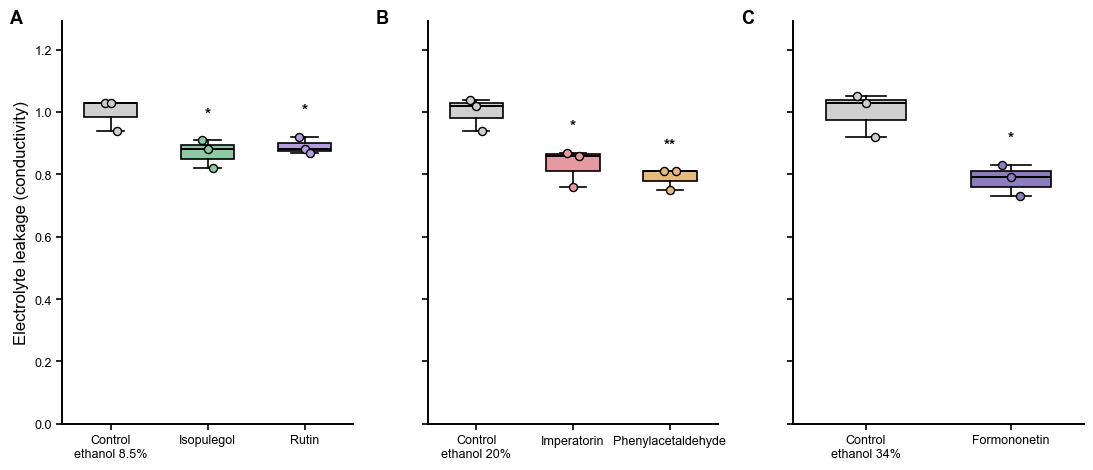

P-values vs matched control:
Isopulegol: p = 0.0321  *
Rutin: p = 0.0475  *
Imperatorin: p = 0.0225  *
Phenylacetaldehyde: p = 0.0071  **
Formononetin: p = 0.0150  *


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# =========================================================
# 1. Input data
# =========================================================
raw_data = [
    ["CK 8.5%", 1, 1.03],
    ["CK 8.5%", 2, 1.03],
    ["CK 8.5%", 3, 0.94],

    ["Isopulegol", 1, 0.91],
    ["Isopulegol", 2, 0.88],
    ["Isopulegol", 3, 0.82],

    ["Rutin", 1, 0.92],
    ["Rutin", 2, 0.88],
    ["Rutin", 3, 0.87],

    ["CK 20%", 1, 1.04],
    ["CK 20%", 2, 1.02],
    ["CK 20%", 3, 0.94],

    ["Imperatorin", 1, 0.87],
    ["Imperatorin", 2, 0.76],
    ["Imperatorin", 3, 0.86],

    ["Phenylacetaldehyde", 1, 0.81],
    ["Phenylacetaldehyde", 2, 0.75],
    ["Phenylacetaldehyde", 3, 0.81],

    ["CK 34%", 1, 1.05],
    ["CK 34%", 2, 1.03],
    ["CK 34%", 3, 0.92],

    ["Formononetin", 1, 0.83],
    ["Formononetin", 2, 0.79],
    ["Formononetin", 3, 0.73],
]

df = pd.DataFrame(raw_data, columns=["Treatment", "Replicate", "Ion leakage"])

# =========================================================
# 2. Panel definitions
# =========================================================
panels = {
    "A": ["CK 8.5%", "Isopulegol", "Rutin"],
    "B": ["CK 20%", "Imperatorin", "Phenylacetaldehyde"],
    "C": ["CK 34%", "Formononetin"],
}

control_map = {
    "Isopulegol": "CK 8.5%",
    "Rutin": "CK 8.5%",
    "Imperatorin": "CK 20%",
    "Phenylacetaldehyde": "CK 20%",
    "Formononetin": "CK 34%",
}

label_map = {
    "CK 8.5%": "Control\nethanol 8.5%",
    "CK 20%": "Control\nethanol 20%",
    "CK 34%": "Control\nethanol 34%",
    "Isopulegol": "Isopulegol",
    "Rutin": "Rutin",
    "Imperatorin": "Imperatorin",
    "Phenylacetaldehyde": "Phenylacetaldehyde",
    "Formononetin": "Formononetin",
}

# =========================================================
# 3. Stronger pastel color palette
# =========================================================
control_color = "#CFCFCF"   # neutral light gray

color_map = {
    "CK 8.5%": control_color,
    "CK 20%": control_color,
    "CK 34%": control_color,
    "Isopulegol": "#8FC9A3",         # stronger pastel green
    "Rutin": "#B39DDB",              # stronger lavender
    "Imperatorin": "#E59AA2",        # dusty coral pink
    "Phenylacetaldehyde": "#E6B980", # warm apricot/beige
    "Formononetin": "#8E7DBE",       # muted plum
}

# =========================================================
# 4. Significance test
# =========================================================
def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

stars = {}
pvals = {}

for treatment in df["Treatment"].unique():
    if treatment.startswith("CK"):
        stars[treatment] = ""
        pvals[treatment] = np.nan
    else:
        ctrl = control_map[treatment]
        vals_treat = df.loc[df["Treatment"] == treatment, "Ion leakage"].values
        vals_ctrl = df.loc[df["Treatment"] == ctrl, "Ion leakage"].values

        # Welch t-test
        p = ttest_ind(vals_treat, vals_ctrl, equal_var=False).pvalue
        stars[treatment] = p_to_star(p)
        pvals[treatment] = p

# =========================================================
# 5. Plot settings
# =========================================================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

fig, axes = plt.subplots(1, 3, figsize=(11, 4.8), sharey=True)
panel_keys = ["A", "B", "C"]

global_ymax = df["Ion leakage"].max()
y_upper = global_ymax * 1.23

# fixed jitter for reproducibility
jitter = np.array([-0.06, 0.00, 0.06])

# =========================================================
# 6. Draw boxplots
# =========================================================
for ax, panel_key in zip(axes, panel_keys):
    treatments = panels[panel_key]
    positions = np.arange(len(treatments))

    data_to_plot = [
        df.loc[df["Treatment"] == trt, "Ion leakage"].values
        for trt in treatments
    ]

    bp = ax.boxplot(
        data_to_plot,
        positions=positions,
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.4),
        boxprops=dict(edgecolor="black", linewidth=1.2),
        whiskerprops=dict(color="black", linewidth=1.2),
        capprops=dict(color="black", linewidth=1.2)
    )

    # Fill colors
    for patch, trt in zip(bp["boxes"], treatments):
        patch.set_facecolor(color_map[trt])

    # Add individual points
    for i, trt in enumerate(treatments):
        vals = df.loc[df["Treatment"] == trt, "Ion leakage"].values
        ax.scatter(
            np.full(len(vals), positions[i]) + jitter[:len(vals)],
            vals,
            s=34,
            facecolors=color_map[trt],
            edgecolors="black",
            linewidths=1.0,
            zorder=3
        )

        # Add significance stars
        star = stars.get(trt, "")
        if star != "":
            y = vals.max()
            ax.text(
                positions[i],
                y + global_ymax * 0.06,
                star,
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold"
            )

    # Axis formatting
    ax.set_xticks(positions)
    ax.set_xticklabels([label_map[t] for t in treatments], fontsize=9)
    ax.set_ylim(0, y_upper)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.4)
    ax.spines["bottom"].set_linewidth(1.4)

    ax.tick_params(axis="y", labelsize=9, width=1.2, length=4)
    ax.tick_params(axis="x", labelsize=9, width=1.2, length=4)

    # Panel label
    ax.text(
        -0.18, 1.03, panel_key,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        ha="left",
        va="top"
    )

# =========================================================
# 7. Global label
# =========================================================
axes[0].set_ylabel("Electrolyte leakage (conductivity)", fontsize=12)

plt.tight_layout()

# =========================================================
# 8. Save
# =========================================================
plt.savefig("C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/ion_leakage/ion_leakage.pdf", bbox_inches="tight")
plt.savefig("C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/ion_leakage/ion_leakage.tiff", dpi=600, bbox_inches="tight")

plt.show()

# =========================================================
# 9. Print p-values
# =========================================================
print("P-values vs matched control:")
for trt, p in pvals.items():
    if not np.isnan(p):
        print(f"{trt}: p = {p:.4f}  {stars[trt]}")

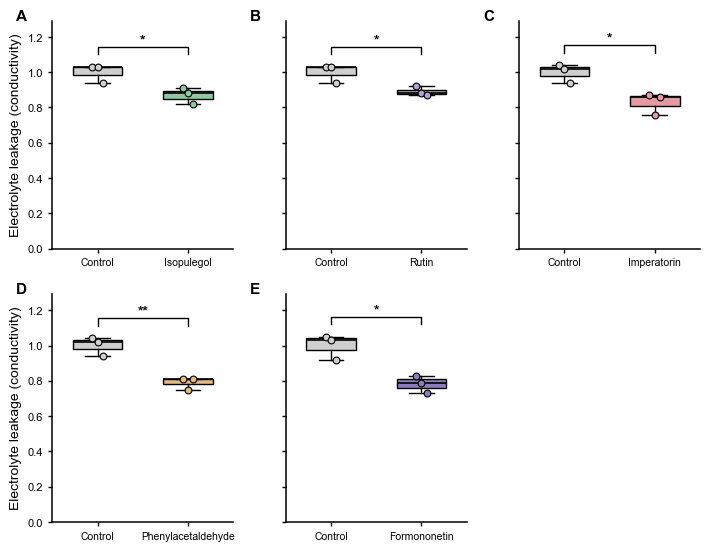

P-values vs matched control:
A. Isopulegol vs CK 8.5%: p = 0.0321  *
B. Rutin vs CK 8.5%: p = 0.0475  *
C. Imperatorin vs CK 20%: p = 0.0225  *
D. Phenylacetaldehyde vs CK 20%: p = 0.0071  **
E. Formononetin vs CK 34%: p = 0.0150  *


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# =========================================================
# 1. Input data
# =========================================================
raw_data = [
    ["CK 8.5%", 1, 1.03],
    ["CK 8.5%", 2, 1.03],
    ["CK 8.5%", 3, 0.94],

    ["Isopulegol", 1, 0.91],
    ["Isopulegol", 2, 0.88],
    ["Isopulegol", 3, 0.82],

    ["Rutin", 1, 0.92],
    ["Rutin", 2, 0.88],
    ["Rutin", 3, 0.87],

    ["CK 20%", 1, 1.04],
    ["CK 20%", 2, 1.02],
    ["CK 20%", 3, 0.94],

    ["Imperatorin", 1, 0.87],
    ["Imperatorin", 2, 0.76],
    ["Imperatorin", 3, 0.86],

    ["Phenylacetaldehyde", 1, 0.81],
    ["Phenylacetaldehyde", 2, 0.75],
    ["Phenylacetaldehyde", 3, 0.81],

    ["CK 34%", 1, 1.05],
    ["CK 34%", 2, 1.03],
    ["CK 34%", 3, 0.92],

    ["Formononetin", 1, 0.83],
    ["Formononetin", 2, 0.79],
    ["Formononetin", 3, 0.73],
]

df = pd.DataFrame(raw_data, columns=["Treatment", "Replicate", "Ion leakage"])

# =========================================================
# 2. Comparison definitions
# =========================================================
comparisons = [
    ("A", "CK 8.5%", "Isopulegol"),
    ("B", "CK 8.5%", "Rutin"),
    ("C", "CK 20%", "Imperatorin"),
    ("D", "CK 20%", "Phenylacetaldehyde"),
    ("E", "CK 34%", "Formononetin"),
]

label_map = {
    "CK 8.5%": "Control",
    "CK 20%": "Control",
    "CK 34%": "Control",
    "Isopulegol": "Isopulegol",
    "Rutin": "Rutin",
    "Imperatorin": "Imperatorin",
    "Phenylacetaldehyde": "Phenylacetaldehyde",
    "Formononetin": "Formononetin",
}

# =========================================================
# 3. Colors
# =========================================================
control_color = "#CFCFCF"

color_map = {
    "CK 8.5%": control_color,
    "CK 20%": control_color,
    "CK 34%": control_color,
    "Isopulegol": "#8FC9A3",
    "Rutin": "#B39DDB",
    "Imperatorin": "#E59AA2",
    "Phenylacetaldehyde": "#E6B980",
    "Formononetin": "#8E7DBE",
}

# =========================================================
# 4. Significance test
# =========================================================
def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

stats_results = {}

for panel, ctrl, trt in comparisons:
    vals_ctrl = df.loc[df["Treatment"] == ctrl, "Ion leakage"].values
    vals_trt = df.loc[df["Treatment"] == trt, "Ion leakage"].values
    p = ttest_ind(vals_trt, vals_ctrl, equal_var=False).pvalue
    stats_results[trt] = {"p": p, "star": p_to_star(p)}

# =========================================================
# 5. Plot settings
# =========================================================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# Double-column style figure
fig, axes = plt.subplots(2, 3, figsize=(7.2, 5.6), sharey=True)
axes = axes.flatten()

global_ymax = df["Ion leakage"].max()
y_upper = global_ymax * 1.23
jitter = np.array([-0.06, 0.00, 0.06])

# =========================================================
# 6. Draw mini-panels
# =========================================================
for ax, (panel, ctrl, trt) in zip(axes[:5], comparisons):
    groups = [ctrl, trt]
    positions = np.arange(2)

    data_to_plot = [
        df.loc[df["Treatment"] == g, "Ion leakage"].values
        for g in groups
    ]

    bp = ax.boxplot(
        data_to_plot,
        positions=positions,
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.2),
        boxprops=dict(edgecolor="black", linewidth=1.0),
        whiskerprops=dict(color="black", linewidth=1.0),
        capprops=dict(color="black", linewidth=1.0)
    )

    for patch, g in zip(bp["boxes"], groups):
        patch.set_facecolor(color_map[g])

    for i, g in enumerate(groups):
        vals = df.loc[df["Treatment"] == g, "Ion leakage"].values
        ax.scatter(
            np.full(len(vals), positions[i]) + jitter[:len(vals)],
            vals,
            s=24,
            facecolors=color_map[g],
            edgecolors="black",
            linewidths=0.8,
            zorder=3
        )

    star = stats_results[trt]["star"]
    if star != "":
        y = max(
            df.loc[df["Treatment"] == ctrl, "Ion leakage"].max(),
            df.loc[df["Treatment"] == trt, "Ion leakage"].max()
        )
        h = global_ymax * 0.04
        y_bracket = y + h * 1.7   # remonte toute la barre
        ax.plot(
            [positions[0], positions[0], positions[1], positions[1]],
            [y_bracket, y_bracket + h, y_bracket + h, y_bracket],
            color="black",
            linewidth=1.0
        )
        ax.text(
            np.mean(positions),
            y_bracket + h * 1.15,
            star,
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax.set_xticks(positions)
    ax.set_xticklabels([label_map[g] for g in groups], fontsize=7.5)
    ax.set_ylim(0, y_upper)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)

    ax.tick_params(axis="y", labelsize=8, width=1.0, length=3)
    ax.tick_params(axis="x", labelsize=7.5, width=1.0, length=3)

    ax.text(
        -0.20, 1.05, panel,
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        ha="left",
        va="top"
    )

# Hide the 6th empty panel
axes[5].axis("off")

# =========================================================
# 7. Global labels
# =========================================================
axes[0].set_ylabel("Electrolyte leakage (conductivity)", fontsize=10)
axes[3].set_ylabel("Electrolyte leakage (conductivity)", fontsize=10)

plt.tight_layout(w_pad=1.0, h_pad=1.2)

# =========================================================
# 8. Save
# =========================================================
plt.savefig(
    "C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/ion_leakage/ion_leakage_5panels_2rows.pdf",
    bbox_inches="tight"
)
plt.savefig(
    "C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/ion_leakage/ion_leakage_5panels_2rows.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# 9. Print p-values
# =========================================================
print("P-values vs matched control:")
for panel, ctrl, trt in comparisons:
    p = stats_results[trt]["p"]
    star = stats_results[trt]["star"]
    print(f"{panel}. {trt} vs {ctrl}: p = {p:.4f}  {star}")

# H2O2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# =========================================================
# 1. Input data
# =========================================================
raw_data = [
    ["CK 8.5%", 1, 268.47],
    ["CK 8.5%", 2, 286.72],
    ["CK 8.5%", 3, 291.56],

    ["Isopulegol", 1, 198.24],
    ["Isopulegol", 2, 174.33],
    ["Isopulegol", 3, 158.47],

    ["Rutin", 1, 204.25],
    ["Rutin", 2, 189.27],
    ["Rutin", 3, 194.83],

    ["CK 20%", 1, 258.42],
    ["CK 20%", 2, 274.57],
    ["CK 20%", 3, 249.62],

    ["Imperatorin", 1, 124.84],
    ["Imperatorin", 2, 125.37],
    ["Imperatorin", 3, 145.29],

    ["Phenylacetaldehyde", 1, 165.21],
    ["Phenylacetaldehyde", 2, 137.43],
    ["Phenylacetaldehyde", 3, 152.79],

    ["CK 34%", 1, 254.21],
    ["CK 34%", 2, 279.22],
    ["CK 34%", 3, 243.53],

    ["Formononetin", 1, 168.45],
    ["Formononetin", 2, 157.32],
    ["Formononetin", 3, 135.74],
]

df = pd.DataFrame(raw_data, columns=["Treatment", "Replicate", "H2O2"])

# =========================================================
# 2. Panel definitions
# =========================================================
panels = {
    "A": ["CK 8.5%", "Isopulegol", "Rutin"],
    "B": ["CK 20%", "Imperatorin", "Phenylacetaldehyde"],
    "C": ["CK 34%", "Formononetin"],
}

control_map = {
    "Isopulegol": "CK 8.5%",
    "Rutin": "CK 8.5%",
    "Imperatorin": "CK 20%",
    "Phenylacetaldehyde": "CK 20%",
    "Formononetin": "CK 34%",
}

label_map = {
    "CK 8.5%": "Control\nethanol 8.5%",
    "CK 20%": "Control\nethanol 20%",
    "CK 34%": "Control\nethanol 34%",
    "Isopulegol": "Isopulegol",
    "Rutin": "Rutin",
    "Imperatorin": "Imperatorin",
    "Phenylacetaldehyde": "Phenylacetaldehyde",
    "Formononetin": "Formononetin",
}

# =========================================================
# 3. Color palette
# =========================================================
control_color = "#CFCFCF"

color_map = {
    "CK 8.5%": control_color,
    "CK 20%": control_color,
    "CK 34%": control_color,
    "Isopulegol": "#8FC9A3",
    "Rutin": "#B39DDB",
    "Imperatorin": "#E59AA2",
    "Phenylacetaldehyde": "#E6B980",
    "Formononetin": "#8E7DBE",
}

# =========================================================
# 4. Significance test
# =========================================================
def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

stars = {}
pvals = {}

for treatment in df["Treatment"].unique():
    if treatment.startswith("CK"):
        stars[treatment] = ""
        pvals[treatment] = np.nan
    else:
        ctrl = control_map[treatment]
        vals_treat = df.loc[df["Treatment"] == treatment, "H2O2"].values
        vals_ctrl = df.loc[df["Treatment"] == ctrl, "H2O2"].values

        # Welch t-test
        p = ttest_ind(vals_treat, vals_ctrl, equal_var=False).pvalue
        stars[treatment] = p_to_star(p)
        pvals[treatment] = p

# =========================================================
# 5. Plot settings
# =========================================================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

fig, axes = plt.subplots(1, 3, figsize=(11, 4.8), sharey=True)
panel_keys = ["A", "B", "C"]

global_ymax = df["H2O2"].max()
y_upper = global_ymax * 1.23

jitter = np.array([-0.06, 0.00, 0.06])

# =========================================================
# 6. Draw boxplots
# =========================================================
for ax, panel_key in zip(axes, panel_keys):
    treatments = panels[panel_key]
    positions = np.arange(len(treatments))

    data_to_plot = [
        df.loc[df["Treatment"] == trt, "H2O2"].values
        for trt in treatments
    ]

    bp = ax.boxplot(
        data_to_plot,
        positions=positions,
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.4),
        boxprops=dict(edgecolor="black", linewidth=1.2),
        whiskerprops=dict(color="black", linewidth=1.2),
        capprops=dict(color="black", linewidth=1.2)
    )

    for patch, trt in zip(bp["boxes"], treatments):
        patch.set_facecolor(color_map[trt])

    for i, trt in enumerate(treatments):
        vals = df.loc[df["Treatment"] == trt, "H2O2"].values
        ax.scatter(
            np.full(len(vals), positions[i]) + jitter[:len(vals)],
            vals,
            s=34,
            facecolors=color_map[trt],
            edgecolors="black",
            linewidths=1.0,
            zorder=3
        )

        star = stars.get(trt, "")
        if star != "":
            y = vals.max()
            ax.text(
                positions[i],
                y + global_ymax * 0.06,
                star,
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold"
            )

    ax.set_xticks(positions)
    ax.set_xticklabels([label_map[t] for t in treatments], fontsize=9)
    ax.set_ylim(0, y_upper)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.4)
    ax.spines["bottom"].set_linewidth(1.4)

    ax.tick_params(axis="y", labelsize=9, width=1.2, length=4)
    ax.tick_params(axis="x", labelsize=9, width=1.2, length=4)

    ax.text(
        -0.18, 1.03, panel_key,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        ha="left",
        va="top"
    )

# =========================================================
# 7. Global label
# =========================================================
axes[0].set_ylabel("H$_2$O$_2$ content", fontsize=12)

plt.tight_layout()

# =========================================================
# 8. Save
# =========================================================
plt.savefig("C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/H2O2/H2O2_content.pdf", bbox_inches="tight")
plt.savefig("C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/H2O2/H2O2_content.tiff", dpi=600, bbox_inches="tight")

plt.show()

# =========================================================
# 9. Print p-values
# =========================================================
print("P-values vs matched control:")
for trt, p in pvals.items():
    if not np.isnan(p):
        print(f"{trt}: p = {p:.4f}  {stars[trt]}")

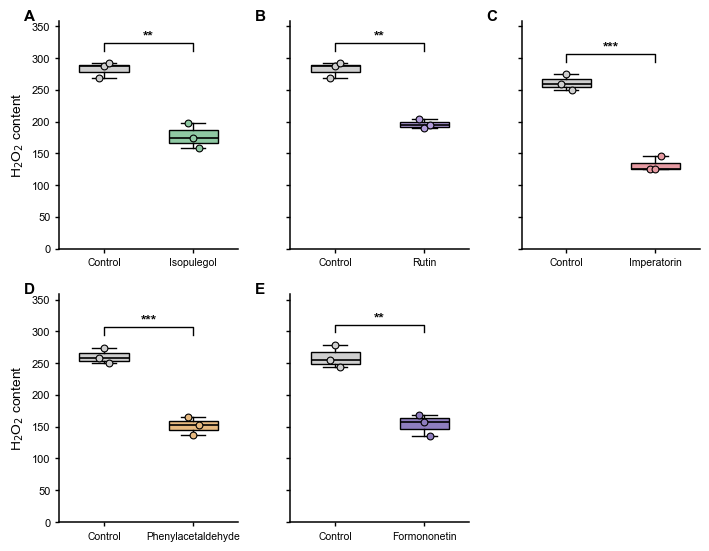

P-values vs matched control:
A. Isopulegol vs CK 8.5%: p = 0.0031  **
B. Rutin vs CK 8.5%: p = 0.0012  **
C. Imperatorin vs CK 20%: p = 0.0002  ***
D. Phenylacetaldehyde vs CK 20%: p = 0.0006  ***
E. Formononetin vs CK 34%: p = 0.0019  **


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# =========================================================
# 1. Input data
# =========================================================
raw_data = [
    ["CK 8.5%", 1, 268.47],
    ["CK 8.5%", 2, 286.72],
    ["CK 8.5%", 3, 291.56],

    ["Isopulegol", 1, 198.24],
    ["Isopulegol", 2, 174.33],
    ["Isopulegol", 3, 158.47],

    ["Rutin", 1, 204.25],
    ["Rutin", 2, 189.27],
    ["Rutin", 3, 194.83],

    ["CK 20%", 1, 258.42],
    ["CK 20%", 2, 274.57],
    ["CK 20%", 3, 249.62],

    ["Imperatorin", 1, 124.84],
    ["Imperatorin", 2, 125.37],
    ["Imperatorin", 3, 145.29],

    ["Phenylacetaldehyde", 1, 165.21],
    ["Phenylacetaldehyde", 2, 137.43],
    ["Phenylacetaldehyde", 3, 152.79],

    ["CK 34%", 1, 254.21],
    ["CK 34%", 2, 279.22],
    ["CK 34%", 3, 243.53],

    ["Formononetin", 1, 168.45],
    ["Formononetin", 2, 157.32],
    ["Formononetin", 3, 135.74],
]

df = pd.DataFrame(raw_data, columns=["Treatment", "Replicate", "H2O2"])

# =========================================================
# 2. Comparison definitions
# =========================================================
comparisons = [
    ("A", "CK 8.5%", "Isopulegol"),
    ("B", "CK 8.5%", "Rutin"),
    ("C", "CK 20%", "Imperatorin"),
    ("D", "CK 20%", "Phenylacetaldehyde"),
    ("E", "CK 34%", "Formononetin"),
]

label_map = {
    "CK 8.5%": "Control",
    "CK 20%": "Control",
    "CK 34%": "Control",
    "Isopulegol": "Isopulegol",
    "Rutin": "Rutin",
    "Imperatorin": "Imperatorin",
    "Phenylacetaldehyde": "Phenylacetaldehyde",
    "Formononetin": "Formononetin",
}

# =========================================================
# 3. Colors
# =========================================================
control_color = "#CFCFCF"

color_map = {
    "CK 8.5%": control_color,
    "CK 20%": control_color,
    "CK 34%": control_color,
    "Isopulegol": "#8FC9A3",
    "Rutin": "#B39DDB",
    "Imperatorin": "#E59AA2",
    "Phenylacetaldehyde": "#E6B980",
    "Formononetin": "#8E7DBE",
}

# =========================================================
# 4. Significance test
# =========================================================
def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

stats_results = {}

for panel, ctrl, trt in comparisons:
    vals_ctrl = df.loc[df["Treatment"] == ctrl, "H2O2"].values
    vals_trt = df.loc[df["Treatment"] == trt, "H2O2"].values
    p = ttest_ind(vals_trt, vals_ctrl, equal_var=False).pvalue
    stats_results[trt] = {"p": p, "star": p_to_star(p)}

# =========================================================
# 5. Plot settings
# =========================================================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

fig, axes = plt.subplots(2, 3, figsize=(7.2, 5.6), sharey=True)
axes = axes.flatten()

global_ymax = df["H2O2"].max()
y_upper = global_ymax * 1.23
jitter = np.array([-0.06, 0.00, 0.06])

# =========================================================
# 6. Draw mini-panels
# =========================================================
for ax, (panel, ctrl, trt) in zip(axes[:5], comparisons):
    groups = [ctrl, trt]
    positions = np.arange(2)

    data_to_plot = [
        df.loc[df["Treatment"] == g, "H2O2"].values
        for g in groups
    ]

    bp = ax.boxplot(
        data_to_plot,
        positions=positions,
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.2),
        boxprops=dict(edgecolor="black", linewidth=1.0),
        whiskerprops=dict(color="black", linewidth=1.0),
        capprops=dict(color="black", linewidth=1.0)
    )

    for patch, g in zip(bp["boxes"], groups):
        patch.set_facecolor(color_map[g])

    for i, g in enumerate(groups):
        vals = df.loc[df["Treatment"] == g, "H2O2"].values
        ax.scatter(
            np.full(len(vals), positions[i]) + jitter[:len(vals)],
            vals,
            s=24,
            facecolors=color_map[g],
            edgecolors="black",
            linewidths=0.8,
            zorder=3
        )

    star = stats_results[trt]["star"]
    if star != "":
        y = max(
            df.loc[df["Treatment"] == ctrl, "H2O2"].max(),
            df.loc[df["Treatment"] == trt, "H2O2"].max()
        )
        h = global_ymax * 0.04
        y_bracket = y + h * 1.7
        ax.plot(
            [positions[0], positions[0], positions[1], positions[1]],
            [y_bracket, y_bracket + h, y_bracket + h, y_bracket],
            color="black",
            linewidth=1.0
        )
        ax.text(
            np.mean(positions),
            y_bracket + h * 1.15,
            star,
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax.set_xticks(positions)
    ax.set_xticklabels([label_map[g] for g in groups], fontsize=7.5)
    ax.set_ylim(0, y_upper)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)

    ax.tick_params(axis="y", labelsize=8, width=1.0, length=3)
    ax.tick_params(axis="x", labelsize=7.5, width=1.0, length=3)

    ax.text(
        -0.20, 1.05, panel,
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        ha="left",
        va="top"
    )

# Hide empty 6th panel
axes[5].axis("off")

# =========================================================
# 7. Global labels
# =========================================================
axes[0].set_ylabel("H$_2$O$_2$ content", fontsize=10)
axes[3].set_ylabel("H$_2$O$_2$ content", fontsize=10)

plt.tight_layout(w_pad=1.0, h_pad=1.2)

# =========================================================
# 8. Save
# =========================================================
plt.savefig(
    "C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/H2O2/H2O2_content_5panels_2rows.pdf",
    bbox_inches="tight"
)
plt.savefig(
    "C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/H2O2/H2O2_content_5panels_2rows.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# 9. Print p-values
# =========================================================
print("P-values vs matched control:")
for panel, ctrl, trt in comparisons:
    p = stats_results[trt]["p"]
    star = stats_results[trt]["star"]
    print(f"{panel}. {trt} vs {ctrl}: p = {p:.4f}  {star}")

# Starch

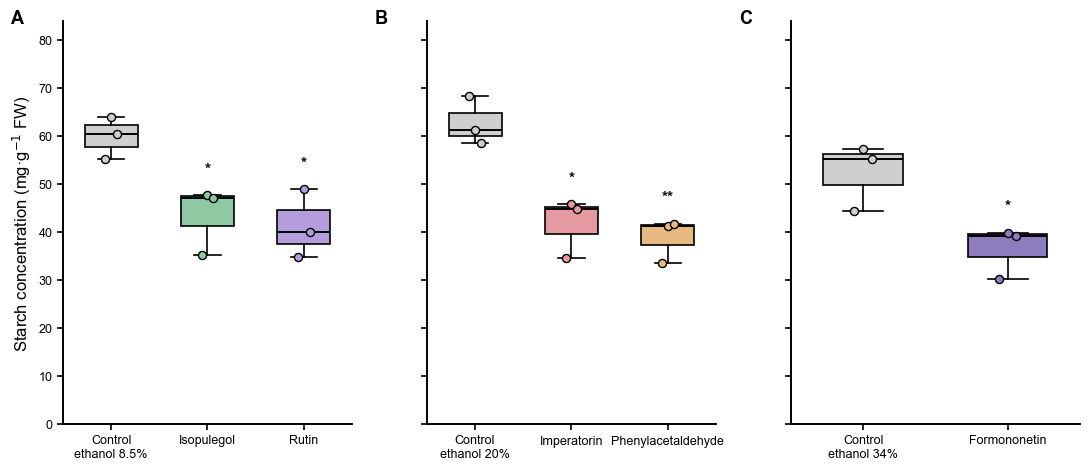

P-values vs matched control:
Isopulegol: p = 0.0347  *
Rutin: p = 0.0257  *
Imperatorin: p = 0.0114  *
Phenylacetaldehyde: p = 0.0038  **
Formononetin: p = 0.0374  *


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# =========================================================
# 1. Input data
# =========================================================
raw_data = [
    ["CK 8.5%", 1, 55.12],
    ["CK 8.5%", 2, 63.97],
    ["CK 8.5%", 3, 60.40],

    ["Isopulegol", 1, 35.18],
    ["Isopulegol", 2, 47.65],
    ["Isopulegol", 3, 47.13],

    ["Rutin", 1, 34.83],
    ["Rutin", 2, 48.91],
    ["Rutin", 3, 40.07],

    ["CK 20%", 1, 68.23],
    ["CK 20%", 2, 61.24],
    ["CK 20%", 3, 58.52],

    ["Imperatorin", 1, 34.56],
    ["Imperatorin", 2, 45.78],
    ["Imperatorin", 3, 44.73],

    ["Phenylacetaldehyde", 1, 33.45],
    ["Phenylacetaldehyde", 2, 41.23],
    ["Phenylacetaldehyde", 3, 41.69],

    ["CK 34%", 1, 44.42],
    ["CK 34%", 2, 57.18],
    ["CK 34%", 3, 55.18],

    ["Formononetin", 1, 30.12],
    ["Formononetin", 2, 39.85],
    ["Formononetin", 3, 39.20],
]

df = pd.DataFrame(raw_data, columns=["Treatment", "Replicate", "Starch"])

# =========================================================
# 2. Panel definitions
# =========================================================
panels = {
    "A": ["CK 8.5%", "Isopulegol", "Rutin"],
    "B": ["CK 20%", "Imperatorin", "Phenylacetaldehyde"],
    "C": ["CK 34%", "Formononetin"],
}

control_map = {
    "Isopulegol": "CK 8.5%",
    "Rutin": "CK 8.5%",
    "Imperatorin": "CK 20%",
    "Phenylacetaldehyde": "CK 20%",
    "Formononetin": "CK 34%",
}

label_map = {
    "CK 8.5%": "Control\nethanol 8.5%",
    "CK 20%": "Control\nethanol 20%",
    "CK 34%": "Control\nethanol 34%",
    "Isopulegol": "Isopulegol",
    "Rutin": "Rutin",
    "Imperatorin": "Imperatorin",
    "Phenylacetaldehyde": "Phenylacetaldehyde",
    "Formononetin": "Formononetin",
}

# =========================================================
# 3. Color palette
# =========================================================
control_color = "#CFCFCF"

color_map = {
    "CK 8.5%": control_color,
    "CK 20%": control_color,
    "CK 34%": control_color,
    "Isopulegol": "#8FC9A3",
    "Rutin": "#B39DDB",
    "Imperatorin": "#E59AA2",
    "Phenylacetaldehyde": "#E6B980",
    "Formononetin": "#8E7DBE",
}

# =========================================================
# 4. Significance test
# =========================================================
def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

stars = {}
pvals = {}

for treatment in df["Treatment"].unique():
    if treatment.startswith("CK"):
        stars[treatment] = ""
        pvals[treatment] = np.nan
    else:
        ctrl = control_map[treatment]
        vals_treat = df.loc[df["Treatment"] == treatment, "Starch"].values
        vals_ctrl = df.loc[df["Treatment"] == ctrl, "Starch"].values

        # Welch t-test
        p = ttest_ind(vals_treat, vals_ctrl, equal_var=False).pvalue
        stars[treatment] = p_to_star(p)
        pvals[treatment] = p

# =========================================================
# 5. Plot settings
# =========================================================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

fig, axes = plt.subplots(1, 3, figsize=(11, 4.8), sharey=True)
panel_keys = ["A", "B", "C"]

global_ymax = df["Starch"].max()
y_upper = global_ymax * 1.23

jitter = np.array([-0.06, 0.00, 0.06])

# =========================================================
# 6. Draw boxplots
# =========================================================
for ax, panel_key in zip(axes, panel_keys):
    treatments = panels[panel_key]
    positions = np.arange(len(treatments))

    data_to_plot = [
        df.loc[df["Treatment"] == trt, "Starch"].values
        for trt in treatments
    ]

    bp = ax.boxplot(
        data_to_plot,
        positions=positions,
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.4),
        boxprops=dict(edgecolor="black", linewidth=1.2),
        whiskerprops=dict(color="black", linewidth=1.2),
        capprops=dict(color="black", linewidth=1.2)
    )

    for patch, trt in zip(bp["boxes"], treatments):
        patch.set_facecolor(color_map[trt])

    for i, trt in enumerate(treatments):
        vals = df.loc[df["Treatment"] == trt, "Starch"].values
        ax.scatter(
            np.full(len(vals), positions[i]) + jitter[:len(vals)],
            vals,
            s=34,
            facecolors=color_map[trt],
            edgecolors="black",
            linewidths=1.0,
            zorder=3
        )

        star = stars.get(trt, "")
        if star != "":
            y = vals.max()
            ax.text(
                positions[i],
                y + global_ymax * 0.06,
                star,
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold"
            )

    ax.set_xticks(positions)
    ax.set_xticklabels([label_map[t] for t in treatments], fontsize=9)
    ax.set_ylim(0, y_upper)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.4)
    ax.spines["bottom"].set_linewidth(1.4)

    ax.tick_params(axis="y", labelsize=9, width=1.2, length=4)
    ax.tick_params(axis="x", labelsize=9, width=1.2, length=4)

    ax.text(
        -0.18, 1.03, panel_key,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        ha="left",
        va="top"
    )

# =========================================================
# 7. Global label
# =========================================================
axes[0].set_ylabel("Starch concentration (mg·g$^{-1}$ FW)", fontsize=12)

plt.tight_layout()

# =========================================================
# 8. Save
# =========================================================
plt.savefig("C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/starch/starch_content.pdf", bbox_inches="tight")
plt.savefig("C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/starch/starch_content.tiff", dpi=600, bbox_inches="tight")

plt.show()

# =========================================================
# 9. Print p-values
# =========================================================
print("P-values vs matched control:")
for trt, p in pvals.items():
    if not np.isnan(p):
        print(f"{trt}: p = {p:.4f}  {stars[trt]}")

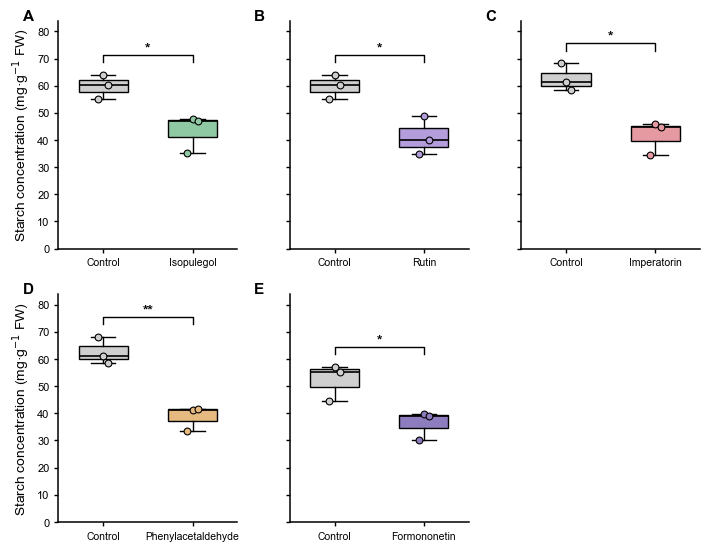

P-values vs matched control:
A. Isopulegol vs CK 8.5%: p = 0.0347  *
B. Rutin vs CK 8.5%: p = 0.0257  *
C. Imperatorin vs CK 20%: p = 0.0114  *
D. Phenylacetaldehyde vs CK 20%: p = 0.0038  **
E. Formononetin vs CK 34%: p = 0.0374  *


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# =========================================================
# 1. Input data
# =========================================================
raw_data = [
    ["CK 8.5%", 1, 55.12],
    ["CK 8.5%", 2, 63.97],
    ["CK 8.5%", 3, 60.40],

    ["Isopulegol", 1, 35.18],
    ["Isopulegol", 2, 47.65],
    ["Isopulegol", 3, 47.13],

    ["Rutin", 1, 34.83],
    ["Rutin", 2, 48.91],
    ["Rutin", 3, 40.07],

    ["CK 20%", 1, 68.23],
    ["CK 20%", 2, 61.24],
    ["CK 20%", 3, 58.52],

    ["Imperatorin", 1, 34.56],
    ["Imperatorin", 2, 45.78],
    ["Imperatorin", 3, 44.73],

    ["Phenylacetaldehyde", 1, 33.45],
    ["Phenylacetaldehyde", 2, 41.23],
    ["Phenylacetaldehyde", 3, 41.69],

    ["CK 34%", 1, 44.42],
    ["CK 34%", 2, 57.18],
    ["CK 34%", 3, 55.18],

    ["Formononetin", 1, 30.12],
    ["Formononetin", 2, 39.85],
    ["Formononetin", 3, 39.20],
]

df = pd.DataFrame(raw_data, columns=["Treatment", "Replicate", "Starch"])

# =========================================================
# 2. Comparison definitions
# =========================================================
comparisons = [
    ("A", "CK 8.5%", "Isopulegol"),
    ("B", "CK 8.5%", "Rutin"),
    ("C", "CK 20%", "Imperatorin"),
    ("D", "CK 20%", "Phenylacetaldehyde"),
    ("E", "CK 34%", "Formononetin"),
]

label_map = {
    "CK 8.5%": "Control",
    "CK 20%": "Control",
    "CK 34%": "Control",
    "Isopulegol": "Isopulegol",
    "Rutin": "Rutin",
    "Imperatorin": "Imperatorin",
    "Phenylacetaldehyde": "Phenylacetaldehyde",
    "Formononetin": "Formononetin",
}

# =========================================================
# 3. Colors
# =========================================================
control_color = "#CFCFCF"

color_map = {
    "CK 8.5%": control_color,
    "CK 20%": control_color,
    "CK 34%": control_color,
    "Isopulegol": "#8FC9A3",
    "Rutin": "#B39DDB",
    "Imperatorin": "#E59AA2",
    "Phenylacetaldehyde": "#E6B980",
    "Formononetin": "#8E7DBE",
}

# =========================================================
# 4. Significance test
# =========================================================
def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

stats_results = {}

for panel, ctrl, trt in comparisons:
    vals_ctrl = df.loc[df["Treatment"] == ctrl, "Starch"].values
    vals_trt = df.loc[df["Treatment"] == trt, "Starch"].values
    p = ttest_ind(vals_trt, vals_ctrl, equal_var=False).pvalue
    stats_results[trt] = {"p": p, "star": p_to_star(p)}

# =========================================================
# 5. Plot settings
# =========================================================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

fig, axes = plt.subplots(2, 3, figsize=(7.2, 5.6), sharey=True)
axes = axes.flatten()

global_ymax = df["Starch"].max()
y_upper = global_ymax * 1.23
jitter = np.array([-0.06, 0.00, 0.06])

# =========================================================
# 6. Draw mini-panels
# =========================================================
for ax, (panel, ctrl, trt) in zip(axes[:5], comparisons):
    groups = [ctrl, trt]
    positions = np.arange(2)

    data_to_plot = [
        df.loc[df["Treatment"] == g, "Starch"].values
        for g in groups
    ]

    bp = ax.boxplot(
        data_to_plot,
        positions=positions,
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.2),
        boxprops=dict(edgecolor="black", linewidth=1.0),
        whiskerprops=dict(color="black", linewidth=1.0),
        capprops=dict(color="black", linewidth=1.0)
    )

    for patch, g in zip(bp["boxes"], groups):
        patch.set_facecolor(color_map[g])

    for i, g in enumerate(groups):
        vals = df.loc[df["Treatment"] == g, "Starch"].values
        ax.scatter(
            np.full(len(vals), positions[i]) + jitter[:len(vals)],
            vals,
            s=24,
            facecolors=color_map[g],
            edgecolors="black",
            linewidths=0.8,
            zorder=3
        )

    star = stats_results[trt]["star"]
    if star != "":
        y = max(
            df.loc[df["Treatment"] == ctrl, "Starch"].max(),
            df.loc[df["Treatment"] == trt, "Starch"].max()
        )
        h = global_ymax * 0.04
        y_bracket = y + h * 1.7
        ax.plot(
            [positions[0], positions[0], positions[1], positions[1]],
            [y_bracket, y_bracket + h, y_bracket + h, y_bracket],
            color="black",
            linewidth=1.0
        )
        ax.text(
            np.mean(positions),
            y_bracket + h * 1.15,
            star,
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax.set_xticks(positions)
    ax.set_xticklabels([label_map[g] for g in groups], fontsize=7.5)
    ax.set_ylim(0, y_upper)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)

    ax.tick_params(axis="y", labelsize=8, width=1.0, length=3)
    ax.tick_params(axis="x", labelsize=7.5, width=1.0, length=3)

    ax.text(
        -0.20, 1.05, panel,
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        ha="left",
        va="top"
    )

# Hide empty 6th panel
axes[5].axis("off")

# =========================================================
# 7. Global labels
# =========================================================
axes[0].set_ylabel("Starch concentration (mg·g$^{-1}$ FW)", fontsize=10)
axes[3].set_ylabel("Starch concentration (mg·g$^{-1}$ FW)", fontsize=10)

plt.tight_layout(w_pad=1.0, h_pad=1.2)

# =========================================================
# 8. Save
# =========================================================
plt.savefig(
    "C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/starch/starch_content_5panels_2rows.pdf",
    bbox_inches="tight"
)
plt.savefig(
    "C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/starch/starch_content_5panels_2rows.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# 9. Print p-values
# =========================================================
print("P-values vs matched control:")
for panel, ctrl, trt in comparisons:
    p = stats_results[trt]["p"]
    star = stats_results[trt]["star"]
    print(f"{panel}. {trt} vs {ctrl}: p = {p:.4f}  {star}")

# Callose

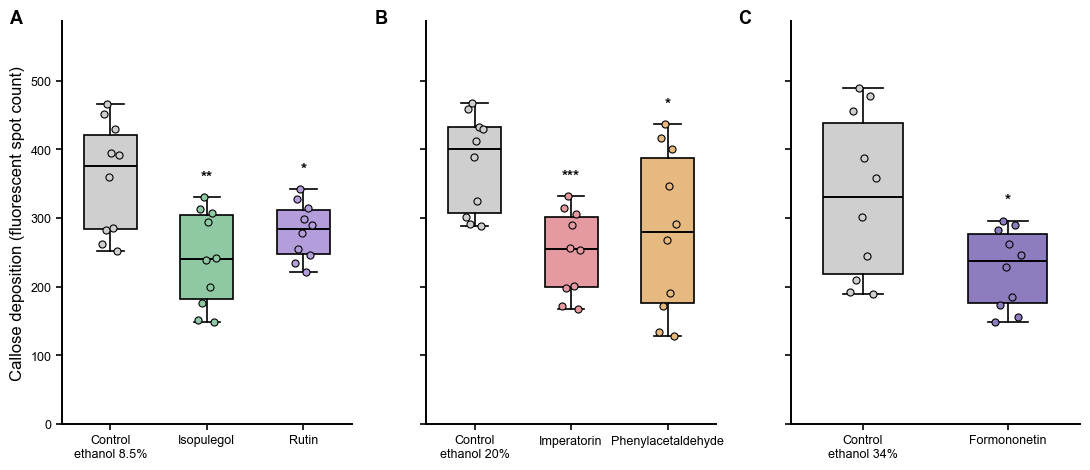

P-values vs matched control:
Isopulegol: p = 0.0027  **
Rutin: p = 0.0192  *
Imperatorin: p = 0.0004  ***
Phenylacetaldehyde: p = 0.0359  *
Formononetin: p = 0.0275  *


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# =========================================================
# 1. Input data
# =========================================================
raw_data = [
    ["CK 8.5%", 1, 262],
    ["CK 8.5%", 2, 451],
    ["CK 8.5%", 3, 283],
    ["CK 8.5%", 4, 466],
    ["CK 8.5%", 5, 359],
    ["CK 8.5%", 6, 394],
    ["CK 8.5%", 7, 285],
    ["CK 8.5%", 8, 429],
    ["CK 8.5%", 9, 252],
    ["CK 8.5%", 10, 391],

    ["Isopulegol", 1, 151],
    ["Isopulegol", 2, 313],
    ["Isopulegol", 3, 176],
    ["Isopulegol", 4, 330],
    ["Isopulegol", 5, 239],
    ["Isopulegol", 6, 294],
    ["Isopulegol", 7, 199],
    ["Isopulegol", 8, 307],
    ["Isopulegol", 9, 148],
    ["Isopulegol", 10, 241],

    ["Rutin", 1, 235],
    ["Rutin", 2, 328],
    ["Rutin", 3, 254],
    ["Rutin", 4, 342],
    ["Rutin", 5, 278],
    ["Rutin", 6, 299],
    ["Rutin", 7, 221],
    ["Rutin", 8, 315],
    ["Rutin", 9, 246],
    ["Rutin", 10, 289],

    ["CK 20%", 1, 302],
    ["CK 20%", 2, 458],
    ["CK 20%", 3, 291],
    ["CK 20%", 4, 467],
    ["CK 20%", 5, 389],
    ["CK 20%", 6, 412],
    ["CK 20%", 7, 325],
    ["CK 20%", 8, 433],
    ["CK 20%", 9, 288],
    ["CK 20%", 10, 429],

    ["Imperatorin", 1, 172],
    ["Imperatorin", 2, 315],
    ["Imperatorin", 3, 198],
    ["Imperatorin", 4, 332],
    ["Imperatorin", 5, 256],
    ["Imperatorin", 6, 289],
    ["Imperatorin", 7, 201],
    ["Imperatorin", 8, 305],
    ["Imperatorin", 9, 167],
    ["Imperatorin", 10, 253],

    ["Phenylacetaldehyde", 1, 134],
    ["Phenylacetaldehyde", 2, 416],
    ["Phenylacetaldehyde", 3, 172],
    ["Phenylacetaldehyde", 4, 437],
    ["Phenylacetaldehyde", 5, 268],
    ["Phenylacetaldehyde", 6, 347],
    ["Phenylacetaldehyde", 7, 190],
    ["Phenylacetaldehyde", 8, 401],
    ["Phenylacetaldehyde", 9, 128],
    ["Phenylacetaldehyde", 10, 291],

    ["CK 34%", 1, 192],
    ["CK 34%", 2, 456],
    ["CK 34%", 3, 210],
    ["CK 34%", 4, 489],
    ["CK 34%", 5, 302],
    ["CK 34%", 6, 388],
    ["CK 34%", 7, 245],
    ["CK 34%", 8, 477],
    ["CK 34%", 9, 189],
    ["CK 34%", 10, 358],

    ["Formononetin", 1, 149],
    ["Formononetin", 2, 282],
    ["Formononetin", 3, 173],
    ["Formononetin", 4, 296],
    ["Formononetin", 5, 229],
    ["Formononetin", 6, 262],
    ["Formononetin", 7, 185],
    ["Formononetin", 8, 289],
    ["Formononetin", 9, 156],
    ["Formononetin", 10, 246],
]

df = pd.DataFrame(raw_data, columns=["Treatment", "Replicate", "Callose"])

# =========================================================
# 2. Panel definitions
# =========================================================
panels = {
    "A": ["CK 8.5%", "Isopulegol", "Rutin"],
    "B": ["CK 20%", "Imperatorin", "Phenylacetaldehyde"],
    "C": ["CK 34%", "Formononetin"],
}

control_map = {
    "Isopulegol": "CK 8.5%",
    "Rutin": "CK 8.5%",
    "Imperatorin": "CK 20%",
    "Phenylacetaldehyde": "CK 20%",
    "Formononetin": "CK 34%",
}

label_map = {
    "CK 8.5%": "Control\nethanol 8.5%",
    "CK 20%": "Control\nethanol 20%",
    "CK 34%": "Control\nethanol 34%",
    "Isopulegol": "Isopulegol",
    "Rutin": "Rutin",
    "Imperatorin": "Imperatorin",
    "Phenylacetaldehyde": "Phenylacetaldehyde",
    "Formononetin": "Formononetin",
}

# =========================================================
# 3. Color palette
# =========================================================
control_color = "#CFCFCF"

color_map = {
    "CK 8.5%": control_color,
    "CK 20%": control_color,
    "CK 34%": control_color,
    "Isopulegol": "#8FC9A3",
    "Rutin": "#B39DDB",
    "Imperatorin": "#E59AA2",
    "Phenylacetaldehyde": "#E6B980",
    "Formononetin": "#8E7DBE",
}

# =========================================================
# 4. Significance test
# =========================================================
def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

stars = {}
pvals = {}

for treatment in df["Treatment"].unique():
    if treatment.startswith("CK"):
        stars[treatment] = ""
        pvals[treatment] = np.nan
    else:
        ctrl = control_map[treatment]
        vals_treat = df.loc[df["Treatment"] == treatment, "Callose"].values
        vals_ctrl = df.loc[df["Treatment"] == ctrl, "Callose"].values

        # Welch t-test
        p = ttest_ind(vals_treat, vals_ctrl, equal_var=False).pvalue
        stars[treatment] = p_to_star(p)
        pvals[treatment] = p

# =========================================================
# 5. Plot settings
# =========================================================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

fig, axes = plt.subplots(1, 3, figsize=(11, 4.8), sharey=True)
panel_keys = ["A", "B", "C"]

global_ymax = df["Callose"].max()
y_upper = global_ymax * 1.20

# jitter spread for 10 points
jitter = np.linspace(-0.09, 0.09, 10)

# =========================================================
# 6. Draw boxplots
# =========================================================
for ax, panel_key in zip(axes, panel_keys):
    treatments = panels[panel_key]
    positions = np.arange(len(treatments))

    data_to_plot = [
        df.loc[df["Treatment"] == trt, "Callose"].values
        for trt in treatments
    ]

    bp = ax.boxplot(
        data_to_plot,
        positions=positions,
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.4),
        boxprops=dict(edgecolor="black", linewidth=1.2),
        whiskerprops=dict(color="black", linewidth=1.2),
        capprops=dict(color="black", linewidth=1.2)
    )

    for patch, trt in zip(bp["boxes"], treatments):
        patch.set_facecolor(color_map[trt])

    for i, trt in enumerate(treatments):
        vals = df.loc[df["Treatment"] == trt, "Callose"].values
        ax.scatter(
            np.full(len(vals), positions[i]) + jitter[:len(vals)],
            vals,
            s=26,
            facecolors=color_map[trt],
            edgecolors="black",
            linewidths=0.8,
            zorder=3
        )

        star = stars.get(trt, "")
        if star != "":
            y = vals.max()
            ax.text(
                positions[i],
                y + global_ymax * 0.04,
                star,
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold"
            )

    ax.set_xticks(positions)
    ax.set_xticklabels([label_map[t] for t in treatments], fontsize=9)
    ax.set_ylim(0, y_upper)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.4)
    ax.spines["bottom"].set_linewidth(1.4)

    ax.tick_params(axis="y", labelsize=9, width=1.2, length=4)
    ax.tick_params(axis="x", labelsize=9, width=1.2, length=4)

    ax.text(
        -0.18, 1.03, panel_key,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        ha="left",
        va="top"
    )

# =========================================================
# 7. Global label
# =========================================================
axes[0].set_ylabel("Callose deposition (fluorescent spot count)", fontsize=12)

plt.tight_layout()

# =========================================================
# 8. Save
# =========================================================
plt.savefig("C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/starch/callose_deposition.pdf", bbox_inches="tight")
plt.savefig("C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/starch/callose_deposition.tiff", dpi=600, bbox_inches="tight")

plt.show()

# =========================================================
# 9. Print p-values
# =========================================================
print("P-values vs matched control:")
for trt, p in pvals.items():
    if not np.isnan(p):
        print(f"{trt}: p = {p:.4f}  {stars[trt]}")

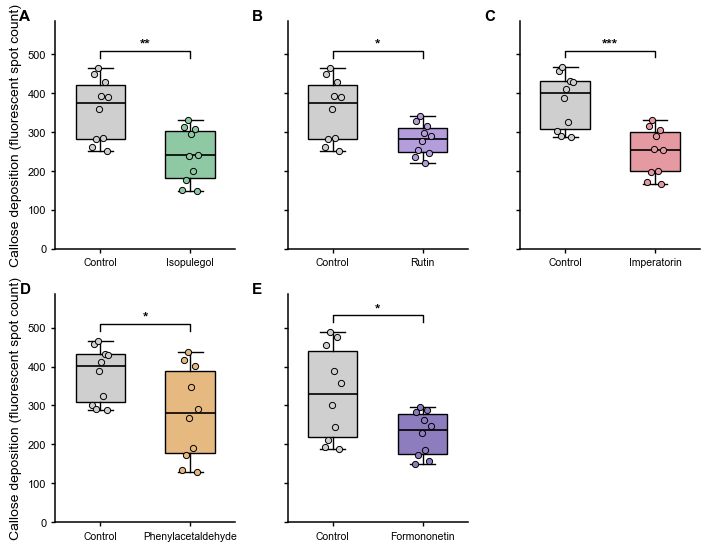

P-values vs matched control:
A. Isopulegol vs CK 8.5%: p = 0.0027  **
B. Rutin vs CK 8.5%: p = 0.0192  *
C. Imperatorin vs CK 20%: p = 0.0004  ***
D. Phenylacetaldehyde vs CK 20%: p = 0.0359  *
E. Formononetin vs CK 34%: p = 0.0275  *


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# =========================================================
# 1. Input data
# =========================================================
raw_data = [
    ["CK 8.5%", 1, 262],
    ["CK 8.5%", 2, 451],
    ["CK 8.5%", 3, 283],
    ["CK 8.5%", 4, 466],
    ["CK 8.5%", 5, 359],
    ["CK 8.5%", 6, 394],
    ["CK 8.5%", 7, 285],
    ["CK 8.5%", 8, 429],
    ["CK 8.5%", 9, 252],
    ["CK 8.5%", 10, 391],

    ["Isopulegol", 1, 151],
    ["Isopulegol", 2, 313],
    ["Isopulegol", 3, 176],
    ["Isopulegol", 4, 330],
    ["Isopulegol", 5, 239],
    ["Isopulegol", 6, 294],
    ["Isopulegol", 7, 199],
    ["Isopulegol", 8, 307],
    ["Isopulegol", 9, 148],
    ["Isopulegol", 10, 241],

    ["Rutin", 1, 235],
    ["Rutin", 2, 328],
    ["Rutin", 3, 254],
    ["Rutin", 4, 342],
    ["Rutin", 5, 278],
    ["Rutin", 6, 299],
    ["Rutin", 7, 221],
    ["Rutin", 8, 315],
    ["Rutin", 9, 246],
    ["Rutin", 10, 289],

    ["CK 20%", 1, 302],
    ["CK 20%", 2, 458],
    ["CK 20%", 3, 291],
    ["CK 20%", 4, 467],
    ["CK 20%", 5, 389],
    ["CK 20%", 6, 412],
    ["CK 20%", 7, 325],
    ["CK 20%", 8, 433],
    ["CK 20%", 9, 288],
    ["CK 20%", 10, 429],

    ["Imperatorin", 1, 172],
    ["Imperatorin", 2, 315],
    ["Imperatorin", 3, 198],
    ["Imperatorin", 4, 332],
    ["Imperatorin", 5, 256],
    ["Imperatorin", 6, 289],
    ["Imperatorin", 7, 201],
    ["Imperatorin", 8, 305],
    ["Imperatorin", 9, 167],
    ["Imperatorin", 10, 253],

    ["Phenylacetaldehyde", 1, 134],
    ["Phenylacetaldehyde", 2, 416],
    ["Phenylacetaldehyde", 3, 172],
    ["Phenylacetaldehyde", 4, 437],
    ["Phenylacetaldehyde", 5, 268],
    ["Phenylacetaldehyde", 6, 347],
    ["Phenylacetaldehyde", 7, 190],
    ["Phenylacetaldehyde", 8, 401],
    ["Phenylacetaldehyde", 9, 128],
    ["Phenylacetaldehyde", 10, 291],

    ["CK 34%", 1, 192],
    ["CK 34%", 2, 456],
    ["CK 34%", 3, 210],
    ["CK 34%", 4, 489],
    ["CK 34%", 5, 302],
    ["CK 34%", 6, 388],
    ["CK 34%", 7, 245],
    ["CK 34%", 8, 477],
    ["CK 34%", 9, 189],
    ["CK 34%", 10, 358],

    ["Formononetin", 1, 149],
    ["Formononetin", 2, 282],
    ["Formononetin", 3, 173],
    ["Formononetin", 4, 296],
    ["Formononetin", 5, 229],
    ["Formononetin", 6, 262],
    ["Formononetin", 7, 185],
    ["Formononetin", 8, 289],
    ["Formononetin", 9, 156],
    ["Formononetin", 10, 246],
]

df = pd.DataFrame(raw_data, columns=["Treatment", "Replicate", "Callose"])

# =========================================================
# 2. Comparison definitions
# =========================================================
comparisons = [
    ("A", "CK 8.5%", "Isopulegol"),
    ("B", "CK 8.5%", "Rutin"),
    ("C", "CK 20%", "Imperatorin"),
    ("D", "CK 20%", "Phenylacetaldehyde"),
    ("E", "CK 34%", "Formononetin"),
]

label_map = {
    "CK 8.5%": "Control",
    "CK 20%": "Control",
    "CK 34%": "Control",
    "Isopulegol": "Isopulegol",
    "Rutin": "Rutin",
    "Imperatorin": "Imperatorin",
    "Phenylacetaldehyde": "Phenylacetaldehyde",
    "Formononetin": "Formononetin",
}

# =========================================================
# 3. Colors
# =========================================================
control_color = "#CFCFCF"

color_map = {
    "CK 8.5%": control_color,
    "CK 20%": control_color,
    "CK 34%": control_color,
    "Isopulegol": "#8FC9A3",
    "Rutin": "#B39DDB",
    "Imperatorin": "#E59AA2",
    "Phenylacetaldehyde": "#E6B980",
    "Formononetin": "#8E7DBE",
}

# =========================================================
# 4. Significance test
# =========================================================
def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

stats_results = {}

for panel, ctrl, trt in comparisons:
    vals_ctrl = df.loc[df["Treatment"] == ctrl, "Callose"].values
    vals_trt = df.loc[df["Treatment"] == trt, "Callose"].values
    p = ttest_ind(vals_trt, vals_ctrl, equal_var=False).pvalue
    stats_results[trt] = {"p": p, "star": p_to_star(p)}

# =========================================================
# 5. Plot settings
# =========================================================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

fig, axes = plt.subplots(2, 3, figsize=(7.2, 5.6), sharey=True)
axes = axes.flatten()

global_ymax = df["Callose"].max()
y_upper = global_ymax * 1.20
jitter = np.linspace(-0.09, 0.09, 10)

# =========================================================
# 6. Draw mini-panels
# =========================================================
for ax, (panel, ctrl, trt) in zip(axes[:5], comparisons):
    groups = [ctrl, trt]
    positions = np.arange(2)

    data_to_plot = [
        df.loc[df["Treatment"] == g, "Callose"].values
        for g in groups
    ]

    bp = ax.boxplot(
        data_to_plot,
        positions=positions,
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.2),
        boxprops=dict(edgecolor="black", linewidth=1.0),
        whiskerprops=dict(color="black", linewidth=1.0),
        capprops=dict(color="black", linewidth=1.0)
    )

    for patch, g in zip(bp["boxes"], groups):
        patch.set_facecolor(color_map[g])

    for i, g in enumerate(groups):
        vals = df.loc[df["Treatment"] == g, "Callose"].values
        ax.scatter(
            np.full(len(vals), positions[i]) + jitter[:len(vals)],
            vals,
            s=20,
            facecolors=color_map[g],
            edgecolors="black",
            linewidths=0.7,
            zorder=3
        )

    star = stats_results[trt]["star"]
    if star != "":
        y = max(
            df.loc[df["Treatment"] == ctrl, "Callose"].max(),
            df.loc[df["Treatment"] == trt, "Callose"].max()
        )
        h = global_ymax * 0.035
        y_bracket = y + h * 1.5
        ax.plot(
            [positions[0], positions[0], positions[1], positions[1]],
            [y_bracket, y_bracket + h, y_bracket + h, y_bracket],
            color="black",
            linewidth=1.0
        )
        ax.text(
            np.mean(positions),
            y_bracket + h * 1.12,
            star,
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax.set_xticks(positions)
    ax.set_xticklabels([label_map[g] for g in groups], fontsize=7.5)
    ax.set_ylim(0, y_upper)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)

    ax.tick_params(axis="y", labelsize=8, width=1.0, length=3)
    ax.tick_params(axis="x", labelsize=7.5, width=1.0, length=3)

    ax.text(
        -0.20, 1.05, panel,
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        ha="left",
        va="top"
    )

# Hide empty 6th panel
axes[5].axis("off")

# =========================================================
# 7. Global labels
# =========================================================
axes[0].set_ylabel("Callose deposition (fluorescent spot count)", fontsize=10)
axes[3].set_ylabel("Callose deposition (fluorescent spot count)", fontsize=10)

plt.tight_layout(w_pad=1.0, h_pad=1.2)

# =========================================================
# 8. Save
# =========================================================
plt.savefig(
    "C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/starch/callose_deposition_5panels_2rows.pdf",
    bbox_inches="tight"
)
plt.savefig(
    "C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/starch/callose_deposition_5panels_2rows.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# 9. Print p-values
# =========================================================
print("P-values vs matched control:")
for panel, ctrl, trt in comparisons:
    p = stats_results[trt]["p"]
    star = stats_results[trt]["star"]
    print(f"{panel}. {trt} vs {ctrl}: p = {p:.4f}  {star}")

# MDA

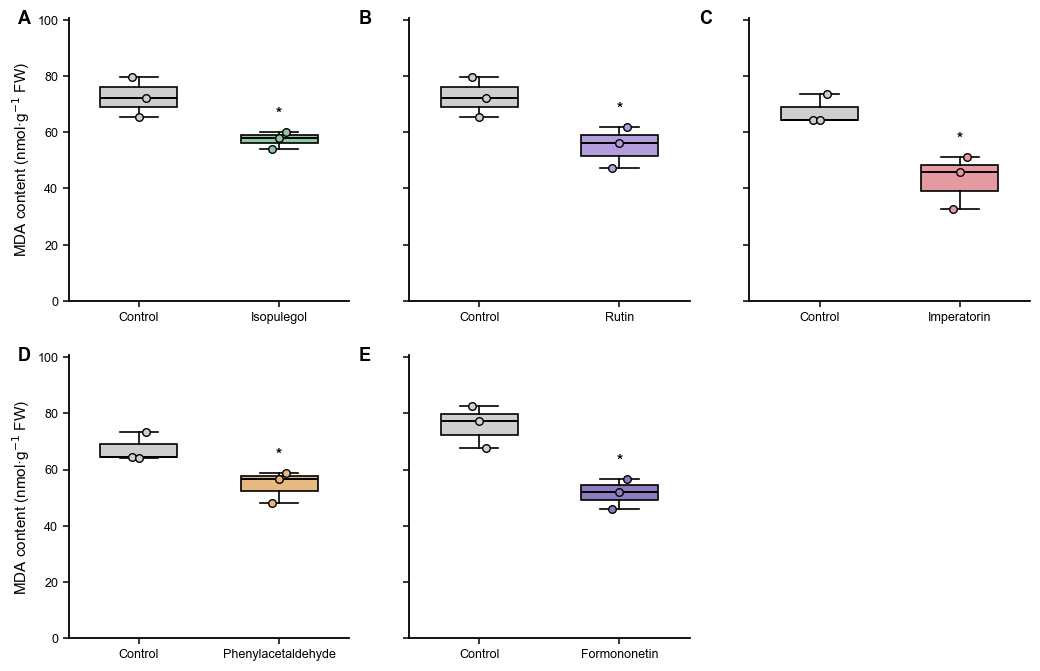

P-values vs matched control:
Isopulegol: p = 0.0484  *
Rutin: p = 0.0416  *
Imperatorin: p = 0.0294  *
Phenylacetaldehyde: p = 0.0462  *
Formononetin: p = 0.0136  *


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# =========================================================
# 1. Input data
# =========================================================
raw_data = [
    ["CK 8.5%", 1, 79.54],
    ["CK 8.5%", 2, 65.52],
    ["CK 8.5%", 3, 72.36],

    ["Isopulegol", 1, 54.13],
    ["Isopulegol", 2, 57.87],
    ["Isopulegol", 3, 59.94],

    ["Rutin", 1, 47.31],
    ["Rutin", 2, 56.13],
    ["Rutin", 3, 61.89],

    ["CK 20%", 1, 64.41],
    ["CK 20%", 2, 64.22],
    ["CK 20%", 3, 73.52],

    ["Imperatorin", 1, 32.52],
    ["Imperatorin", 2, 45.83],
    ["Imperatorin", 3, 51.16],

    ["Phenylacetaldehyde", 1, 48.24],
    ["Phenylacetaldehyde", 2, 56.79],
    ["Phenylacetaldehyde", 3, 58.83],

    ["CK 34%", 1, 82.46],
    ["CK 34%", 2, 77.24],
    ["CK 34%", 3, 67.53],

    ["Formononetin", 1, 45.85],
    ["Formononetin", 2, 52.16],
    ["Formononetin", 3, 56.77],
]

df = pd.DataFrame(raw_data, columns=["Treatment", "Replicate", "MDA"])

# =========================================================
# 2. Panel definitions (5 plots)
# =========================================================
panels = {
    "A": ["CK 8.5%", "Isopulegol"],
    "B": ["CK 8.5%", "Rutin"],
    "C": ["CK 20%", "Imperatorin"],
    "D": ["CK 20%", "Phenylacetaldehyde"],
    "E": ["CK 34%", "Formononetin"],
}

control_map = {
    "Isopulegol": "CK 8.5%",
    "Rutin": "CK 8.5%",
    "Imperatorin": "CK 20%",
    "Phenylacetaldehyde": "CK 20%",
    "Formononetin": "CK 34%",
}

label_map = {
    "CK 8.5%": "Control",
    "CK 20%": "Control",
    "CK 34%": "Control",
    "Isopulegol": "Isopulegol",
    "Rutin": "Rutin",
    "Imperatorin": "Imperatorin",
    "Phenylacetaldehyde": "Phenylacetaldehyde",
    "Formononetin": "Formononetin",
}

# =========================================================
# 3. Color palette
# =========================================================
control_color = "#CFCFCF"

color_map = {
    "CK 8.5%": control_color,
    "CK 20%": control_color,
    "CK 34%": control_color,
    "Isopulegol": "#8FC9A3",
    "Rutin": "#B39DDB",
    "Imperatorin": "#E59AA2",
    "Phenylacetaldehyde": "#E6B980",
    "Formononetin": "#8E7DBE",
}

# =========================================================
# 4. Significance test
# =========================================================
def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

stars = {}
pvals = {}

for treatment in df["Treatment"].unique():
    if treatment.startswith("CK"):
        stars[treatment] = ""
        pvals[treatment] = np.nan
    else:
        ctrl = control_map[treatment]
        vals_treat = df.loc[df["Treatment"] == treatment, "MDA"].values
        vals_ctrl = df.loc[df["Treatment"] == ctrl, "MDA"].values
        p = ttest_ind(vals_treat, vals_ctrl, equal_var=False).pvalue
        stars[treatment] = p_to_star(p)
        pvals[treatment] = p

# =========================================================
# 5. Plot settings
# =========================================================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

fig, axes = plt.subplots(2, 3, figsize=(10.5, 6.8), sharey=True)
axes = axes.flatten()

panel_keys = ["A", "B", "C", "D", "E"]

global_ymax = df["MDA"].max()
y_upper = global_ymax * 1.22
jitter = np.array([-0.05, 0.00, 0.05])

# =========================================================
# 6. Draw boxplots
# =========================================================
for ax, panel_key in zip(axes[:5], panel_keys):
    treatments = panels[panel_key]
    positions = np.arange(len(treatments))

    data_to_plot = [
        df.loc[df["Treatment"] == trt, "MDA"].values
        for trt in treatments
    ]

    bp = ax.boxplot(
        data_to_plot,
        positions=positions,
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.4),
        boxprops=dict(edgecolor="black", linewidth=1.2),
        whiskerprops=dict(color="black", linewidth=1.2),
        capprops=dict(color="black", linewidth=1.2)
    )

    for patch, trt in zip(bp["boxes"], treatments):
        patch.set_facecolor(color_map[trt])

    for i, trt in enumerate(treatments):
        vals = df.loc[df["Treatment"] == trt, "MDA"].values
        ax.scatter(
            np.full(len(vals), positions[i]) + jitter[:len(vals)],
            vals,
            s=30,
            facecolors=color_map[trt],
            edgecolors="black",
            linewidths=1.0,
            zorder=3
        )

        star = stars.get(trt, "")
        if star != "":
            y = vals.max()
            ax.text(
                positions[i],
                y + global_ymax * 0.05,
                star,
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold"
            )

    ax.set_xticks(positions)
    ax.set_xticklabels([label_map[t] for t in treatments], fontsize=9)
    ax.set_ylim(0, y_upper)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.3)
    ax.spines["bottom"].set_linewidth(1.3)

    ax.tick_params(axis="y", labelsize=9, width=1.1, length=4)
    ax.tick_params(axis="x", labelsize=9, width=1.1, length=4)

    ax.text(
        -0.18, 1.03, panel_key,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        ha="left",
        va="top"
    )

# Hide empty 6th panel
axes[5].axis("off")

# =========================================================
# 7. Global labels
# =========================================================
axes[0].set_ylabel("MDA content (nmol·g$^{-1}$ FW)", fontsize=11)
axes[3].set_ylabel("MDA content (nmol·g$^{-1}$ FW)", fontsize=11)

plt.tight_layout(w_pad=1.2, h_pad=1.8)

# =========================================================
# 8. Save
# =========================================================
plt.savefig(
    "C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/MDA/mda_content_2rows.pdf",
    bbox_inches="tight"
)
plt.savefig(
    "C:/Users/tamer/Documents/PhD/Progress reports/thèse/Chapter_4_Metabolome/MDA/mda_content_2rows.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# 9. Print p-values
# =========================================================
print("P-values vs matched control:")
for trt, p in pvals.items():
    if not np.isnan(p):
        print(f"{trt}: p = {p:.4f}  {stars[trt]}")